# Notebook 1 — Understanding the Alberta Electricity Market

## Overview

This notebook establishes the operational context for the project. It validates the common dataset, describes Alberta's long-term supply and demand transition, summarizes normal operating patterns and high-price events, and develops hypotheses for forecasting work.

The results are descriptive. They identify patterns and research directions but do not establish causality or predictive value.

## Executive Summary

- Average Alberta Internal Load increased by roughly **10%** between 2015 and 2024.
- Coal fell from about **64%** to less than **3%** of total system generation as gas, wind, and solar expanded.
- Reported maximum capacity increased by approximately **6.8 GW**, yet high-price events became more frequent after 2021.
- The 2021–2023 period forms a distinct high-price regime rather than a collection of isolated anomalies.
- Net load has a clear nonlinear association with price, while imports, gas, outages, and renewable output remain state-dependent.
- These findings motivate time-aware tests of system margin, net load, intertie saturation, fuel-cost interactions, and seasonal regimes.

## 1. Import and Data Validation

### 1.1 Import Libraries and Load Data

In [1]:
# ---------------------------------------------------------------------
# Configure project imports and notebook environment
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# ---------------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import (
    PA_TABLE_PARQUET,
    INTERTIES_HOUR_AHEAD_PARQUET,
    INTERTIE_CAPABILITY_PARQUET,
    GENERATION_PARQUET,
    OUTAGES_PARQUET,
    CALENDAR_FEATURES,
    LOAD_WEATHER_FEATURES,
    MARKET_FEATURES,
    RENEWABLE_WEATHER_FEATURES,
    RANDOM_SEED,
)

# ---------------------------------------------------------------------
# Configure notebook settings
# ---------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------
# Load processed datasets
# ---------------------------------------------------------------------

pa_hourly = pd.read_parquet(PA_TABLE_PARQUET)
interties_hour_ahead = pd.read_parquet(INTERTIES_HOUR_AHEAD_PARQUET)
intertie_capability = pd.read_parquet(INTERTIE_CAPABILITY_PARQUET)
generation = pd.read_parquet(GENERATION_PARQUET)
outages = pd.read_parquet(OUTAGES_PARQUET)
calendar = pd.read_parquet(CALENDAR_FEATURES)
weather = pd.read_parquet(LOAD_WEATHER_FEATURES)
market = pd.read_parquet(MARKET_FEATURES)
renewables = pd.read_parquet(RENEWABLE_WEATHER_FEATURES)

### 1.2 Dataset Overview

In [2]:
# ---------------------------------------------------------------------
# Summarize the processed datasets
# ---------------------------------------------------------------------

summary = []

datasets = {
    "pa_hourly": pa_hourly,
    "interties": interties_hour_ahead,
    "intertie_capability": intertie_capability,
    "generation": generation,
    "outages": outages,
    "calendar": calendar,
    "weather": weather,
    "market": market,
    "renewables": renewables,
}

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Start": df["timestamp_utc"].min(),
        "End": df["timestamp_utc"].max(),
        "Duplicate timestamps": df["timestamp_utc"].duplicated().sum(),
        "Missing values": int(df.isna().sum().sum()),
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / 1e6, 2),
    })

dataset_summary = pd.DataFrame(summary)

dataset_summary

,Dataset,Rows,Columns,Start,End,Duplicate timestamps,Missing values,Memory (MB)
0,pa_hourly,100055,5,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,0,4.00
1,interties,136583,8,2010-01-01 07:00:00+00:00,2025-08-01 05:00:00+00:00,0,62786,8.74
2,intertie_capability,100033,9,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,0,7.20
3,generation,100055,61,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,985430,48.83
4,outages,100033,13,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,197686,10.40
5,calendar,100776,46,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0,19.16
6,weather,87672,73,2015-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00,0,110326,45.68
7,market,100055,264,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,739383,185.12
8,renewables,100776,51,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,44295,41.12


In [45]:
# ---------------------------------------------------------------------
# Summarize missing values by dataset
# ---------------------------------------------------------------------

for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing.gt(0)].sort_values(ascending=False)

    print(
        f"{name}: "
        f"{len(missing)} columns with missing values, "
        f"{missing.sum():,} missing observations"
    )

    if not missing.empty:
        display(
            missing.head(5).to_frame("missing_rows")
        )

calendar: 0 columns with missing values, 0 missing observations
market: 201 columns with missing values, 739,383 missing observations


,missing_rows
gas_fired_steam_outage,53374
storage_outage,51165
storage_outage_mw,51165
dual_fuel_outage,50037
solar_outage,25678


intertie_capability: 0 columns with missing values, 0 missing observations
generation: 25 columns with missing values, 985,430 missing observations


,missing_rows
gas_fired_steam_system_available,53352
gas_fired_steam_system_generation,53352
gas_fired_steam_maximum_capacity,53352
gas_fired_steam_system_capacity,53352
gas_fired_steam_total_generation,53352


weather: 7 columns with missing values, 110,326 missing observations


,missing_rows
load_weighted_heat_index_c,86824
load_weighted_wind_chill_c,23456
load_temperature_change_24h_c,24
load_temperature_change_12h_c,12
load_temperature_change_6h_c,6


renewables: 1 columns with missing values, 44,295 missing observations


,missing_rows
solar_clear_sky_radiation_ratio,44295


#### Observations

- No processed dataset contains duplicate timestamps.
- `pa_hourly`, intertie capability, and calendar data are complete; the hour-ahead price forecast has only four missing observations.
- Intertie gaps are concentrated before the Montana-Alberta Tie Line entered service.
- Generation and outage gaps are mainly structural, reflecting technology entry, retirement, or reporting changes.
- Weather gaps often represent variables that are physically undefined outside specific conditions.
- Initial lag and rolling-feature gaps are expected where sufficient history is unavailable.

The missingness pattern is structured and explainable rather than evidence of broad data-quality failure.

### 1.3 Validate External Data Coverage

In [4]:
# ---------------------------------------------------------------------
# Validate historical Montana intertie coverage
# ---------------------------------------------------------------------

# Identify the first reported Montana import and export observations.
print(
    interties_hour_ahead.loc[
        interties_hour_ahead["import_mt"].notna(),
        "timestamp_utc",
    ].min()
)

print(
    interties_hour_ahead.loc[
        interties_hour_ahead["export_mt"].notna(),
        "timestamp_utc",
    ].min()
)

# Confirm that no missing values remain after historical reporting begins.
cutoff = pd.Timestamp("2013-08-01 06:00:00", tz="UTC")

mt_missing = (
    interties_hour_ahead.loc[
        interties_hour_ahead["timestamp_utc"] >= cutoff,
        ["import_mt", "export_mt"],
    ]
    .isna()
    .sum()
)

print(mt_missing)

2013-08-01 06:00:00+00:00
2013-08-01 06:00:00+00:00
import_mt    0
export_mt    0
dtype: int64


#### Montana Intertie Reporting

Montana imports and exports are unavailable before August 2013 because the intertie was not yet operational and publicly reported. Both series are complete from **2013-08-01 06:00 UTC**, so the earlier values represent a reporting boundary rather than random missingness.

In [5]:
# ---------------------------------------------------------------------
# Validate generation coverage by reported fuel category
# ---------------------------------------------------------------------

generation_coverage = []

generation_category_columns = [
    column
    for column in generation.columns
    if column.endswith("_system_generation")
    and column != "total_system_generation"
]

for column in generation_category_columns:
    reported = generation[column].notna()
    fuel = column.removesuffix("_system_generation").replace("_", " ").title()

    generation_coverage.append({
        "fuel_category": fuel,
        "first_reported": generation.loc[reported, "timestamp_utc"].min(),
        "last_reported": generation.loc[reported, "timestamp_utc"].max(),
        "observed_hours": int(reported.sum()),
        "coverage_pct": reported.mean() * 100,
    })

generation_coverage = (
    pd.DataFrame(generation_coverage)
    .sort_values("first_reported")
    .reset_index(drop=True)
)

display(generation_coverage.round({"coverage_pct": 2}))


,fuel_category,first_reported,last_reported,observed_hours,coverage_pct
0,Coal,2015-01-01 07:00:00+00:00,2024-07-01 05:00:00+00:00,83255,83.21
1,Cogeneration,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
2,Combined Cycle,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
3,Hydro,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
4,Other,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
5,Simple Cycle,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
6,Wind,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
7,Solar,2017-12-05 07:00:00+00:00,2026-06-01 05:00:00+00:00,74399,74.36
8,Dual Fuel,2018-03-05 07:00:00+00:00,2024-07-12 05:00:00+00:00,49920,49.89
9,Storage,2020-11-01 06:00:00+00:00,2026-06-01 05:00:00+00:00,48912,48.89


#### Generation Dataset Coverage

Coverage changes align with Alberta's fleet transition and AESO classification changes. Solar begins in December 2017, storage in November 2020, and Gas-Fired Steam becomes a separate category in 2021. Dual Fuel is reported from 2018 to July 2024, while Coal ends in July 2024.

Within each fuel category, generation and capacity measures share the same coverage window. These blocks are therefore treated as structurally unavailable, not automatically imputed. The net-load calculation makes one narrow exception: pre-reporting utility-scale solar is explicitly interpreted as zero output.

### 1.4 Merge

In [6]:
# ---------------------------------------------------------------------
# Configure the master dataset merge
# ---------------------------------------------------------------------

merge_key = "timestamp_utc"

# Calendar is the canonical source for timestamp-derived features.
# Placing it first preserves its values when identical calendar columns
# also appear in another feature dataset.
datasets = {
    "calendar": calendar,
    "market": market,
    "intertie_capability": intertie_capability,
    "generation": generation,
    "weather": weather,
    "renewables": renewables,
}

duplicate_columns_removed = []


# ---------------------------------------------------------------------
# Validate merge keys and timestamp uniqueness
# ---------------------------------------------------------------------

for dataset_name, df in datasets.items():

    if merge_key not in df.columns:
        raise KeyError(
            f"{merge_key!r} is missing from dataset "
            f"{dataset_name!r}."
        )

    duplicate_timestamps = df[merge_key].duplicated().sum()

    if duplicate_timestamps:
        raise ValueError(
            f"Dataset {dataset_name!r} contains "
            f"{duplicate_timestamps:,} duplicate timestamps."
        )


# ---------------------------------------------------------------------
# Initialize the master dataset with the canonical calendar table
# ---------------------------------------------------------------------

first_name, first_df = next(iter(datasets.items()))

master = (
    first_df
    .sort_values(merge_key)
    .copy()
)


# ---------------------------------------------------------------------
# Merge feature datasets and reconcile overlapping columns
# ---------------------------------------------------------------------

for dataset_name, df in list(datasets.items())[1:]:

    incoming = (
        df
        .sort_values(merge_key)
        .copy()
    )

    overlapping_columns = sorted(
        (set(master.columns) & set(incoming.columns))
        - {merge_key}
    )

    columns_to_drop = []

    for column in overlapping_columns:

        comparison = (
            master[[merge_key, column]]
            .merge(
                incoming[[merge_key, column]],
                on=merge_key,
                how="inner",
                suffixes=("_master", "_incoming"),
                validate="one_to_one",
            )
        )

        master_col = f"{column}_master"
        incoming_col = f"{column}_incoming"

        values_match = (
            comparison[master_col].eq(
                comparison[incoming_col]
            )
            | (
                comparison[master_col].isna()
                & comparison[incoming_col].isna()
            )
        )

        if values_match.all():

            # Retain the version already present in the master dataset.
            columns_to_drop.append(column)

            duplicate_columns_removed.append(
                {
                    "incoming_dataset": dataset_name,
                    "column_removed": column,
                }
            )

        else:

            discrepancies = comparison.loc[
                ~values_match.fillna(False),
                [
                    merge_key,
                    master_col,
                    incoming_col,
                ],
            ]

            print(
                f"\nConflicting duplicate column: {column!r}"
                f"\nIncoming dataset: {dataset_name!r}"
                f"\nMismatched rows: {len(discrepancies):,}"
            )

            display(discrepancies.head(50))

            raise ValueError(
                f"Column {column!r} exists in both master and "
                f"{dataset_name!r}, but the values are not identical."
            )

    incoming = incoming.drop(
        columns=columns_to_drop
    )

    # Retain only timestamps covered by every required dataset.
    master = master.merge(
        incoming,
        on=merge_key,
        how="inner",
        validate="one_to_one",
    )


# ---------------------------------------------------------------------
# Finalize and audit the master dataset
# ---------------------------------------------------------------------

master = (
    master
    .sort_values(merge_key)
    .reset_index(drop=True)
)

suffixed_columns = [
    column
    for column in master.columns
    if column.endswith("_x")
    or column.endswith("_y")
]

calendar_columns = [
    column
    for column in calendar.columns
    if column != merge_key
]

missing_calendar_columns = [
    column
    for column in calendar_columns
    if column not in master.columns
]

print(f"Shape: {master.shape}")
print(f"Start: {master[merge_key].min()}")
print(f"End:   {master[merge_key].max()}")

print(
    f"Duplicate timestamps: "
    f"{master[merge_key].duplicated().sum()}"
)

print(
    f"Missing values: "
    f"{master.isna().sum().sum():,}"
)

print(
    f"Identical duplicate columns removed: "
    f"{len(duplicate_columns_removed)}"
)

print(
    f"Calendar columns retained: "
    f"{len(calendar_columns) - len(missing_calendar_columns)}"
    f"/{len(calendar_columns)}"
)

print(
    f"Unexpected suffixed columns: "
    f"{len(suffixed_columns)}"
)

if duplicate_columns_removed:

    duplicate_audit = pd.DataFrame(duplicate_columns_removed)

    display(
        duplicate_audit
        .groupby("incoming_dataset")
        .size()
        .rename("identical_columns_removed")
        .to_frame()
    )

if missing_calendar_columns:
    raise ValueError(
        "The following canonical calendar columns are missing "
        f"from master: {missing_calendar_columns}"
    )

if suffixed_columns:
    raise ValueError(
        "Unexpected merge suffix columns remain: "
        f"{suffixed_columns}"
    )

Shape: (87665, 452)
Start: 2015-01-01 07:00:00+00:00
End:   2024-12-31 23:00:00+00:00
Duplicate timestamps: 0
Missing values: 1,236,776
Identical duplicate columns removed: 47
Calendar columns retained: 45/45
Unexpected suffixed columns: 0


,identical_columns_removed
incoming_dataset,
market,45
weather,2


In [7]:
# ---------------------------------------------------------------------
# Audit missingness in the master dataset
# ---------------------------------------------------------------------

missing_audit = (
    master
    .isna()
    .sum()
    .rename("missing_rows")
    .to_frame()
)

missing_audit["missing_pct"] = (
    missing_audit["missing_rows"]
    / len(master)
    * 100
)

missing_audit = (
    missing_audit
    .query("missing_rows > 0")
    .sort_values(
        ["missing_pct", "missing_rows"],
        ascending=False,
    )
)

print(
    f"Columns with missing values: "
    f"{len(missing_audit):,} / {master.shape[1]:,}"
)

display(
    missing_audit.head(10).style.set_table_attributes(
        'style="display:block; max-height:400px; overflow:auto;"'
    )
)

Columns with missing values: 202 / 452


,missing_rows,missing_pct
load_weighted_heat_index_c,86817,99.032681
gas_fired_steam_outage,53352,60.858952
gas_fired_steam_system_generation,53352,60.858952
gas_fired_steam_total_generation,53352,60.858952
gas_fired_steam_system_available,53352,60.858952
gas_fired_steam_system_capacity,53352,60.858952
gas_fired_steam_maximum_capacity,53352,60.858952
storage_outage,51143,58.339132
storage_outage_mw,51143,58.339132
storage_system_generation,51143,58.339132


#### Merge Missingness Audit

The merge introduces no unexpected missingness. Remaining gaps fall into four groups:

- **Reporting boundaries:** technology categories are unavailable before introduction or after retirement or reclassification.
- **Conditionally defined weather:** heat index and wind chill exist only under applicable meteorological conditions.
- **Undefined solar ratios:** clear-sky ratios are unavailable when the denominator is zero, especially at night.
- **Lag and rolling windows:** initial observations lack sufficient history by construction.

The merge also validates timestamp uniqueness, reconciles overlapping columns, and preserves the canonical calendar fields. `master` is the authoritative dataframe for every analysis below; analysis-only variables are kept separate and never appended to it.

> **Pipeline note:** Once the canonical master artifact is finalized, the merge can move to a dedicated builder and this notebook can load and audit that artifact.

In [8]:
# ---------------------------------------------------------------------
# Confirm the common analytical sample and annual coverage
# ---------------------------------------------------------------------

print(
    "Primary analysis sample:",
    master["timestamp_utc"].min(),
    "to",
    master["timestamp_utc"].max(),
)

annual_analysis_coverage = (
    master.groupby("year_alberta")
    .agg(
        first_timestamp=("timestamp_utc", "min"),
        last_timestamp=("timestamp_utc", "max"),
        observed_hours=("timestamp_utc", "size"),
    )
)

annual_analysis_coverage["expected_hours"] = (
    annual_analysis_coverage.index.map(
        lambda year: 8784
        if pd.Timestamp(year=year, month=12, day=31).is_leap_year
        else 8760
    )
)

annual_analysis_coverage["coverage_pct"] = (
    annual_analysis_coverage["observed_hours"]
    / annual_analysis_coverage["expected_hours"]
    * 100
)

annual_analysis_coverage["coverage_note"] = np.where(
    annual_analysis_coverage["observed_hours"]
    == annual_analysis_coverage["expected_hours"],
    "Complete local calendar year",
    "Partial local calendar year",
)

display(annual_analysis_coverage.round({"coverage_pct": 3}))


Primary analysis sample: 2015-01-01 07:00:00+00:00 to 2024-12-31 23:00:00+00:00


,first_timestamp,last_timestamp,observed_hours,expected_hours,coverage_pct,coverage_note
year_alberta,,,,,,
2015,2015-01-01 07:00:00+00:00,2016-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2016,2016-01-01 07:00:00+00:00,2017-01-01 06:00:00+00:00,8784,8784,100.00,Complete local calendar year
2017,2017-01-01 07:00:00+00:00,2018-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2018,2018-01-01 07:00:00+00:00,2019-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2019,2019-01-01 07:00:00+00:00,2020-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2020,2020-01-01 07:00:00+00:00,2021-01-01 06:00:00+00:00,8784,8784,100.00,Complete local calendar year
2021,2021-01-01 07:00:00+00:00,2022-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2022,2022-01-01 07:00:00+00:00,2023-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2023,2023-01-01 07:00:00+00:00,2024-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year


In [9]:
# ---------------------------------------------------------------------
# Validate continuous hourly timestamp coverage
# ---------------------------------------------------------------------

# The endpoints are already timezone-aware UTC timestamps.
expected_timestamps = pd.date_range(
    start=master["timestamp_utc"].min(),
    end=master["timestamp_utc"].max(),
    freq="h",
)

observed_timestamps = pd.DatetimeIndex(
    master["timestamp_utc"].sort_values()
)

missing_timestamps = expected_timestamps.difference(observed_timestamps)
unexpected_timestamps = observed_timestamps.difference(expected_timestamps)

timestamp_gaps = (
    master["timestamp_utc"]
    .sort_values()
    .diff()
)

irregular_intervals = timestamp_gaps.iloc[1:].ne(
    pd.Timedelta(hours=1)
).sum()

print(f"Expected timestamps:   {len(expected_timestamps):,}")
print(f"Observed timestamps:   {len(observed_timestamps):,}")
print(f"Missing timestamps:    {len(missing_timestamps):,}")
print(f"Unexpected timestamps: {len(unexpected_timestamps):,}")
print(f"Irregular intervals:   {irregular_intervals:,}")

if (
    len(missing_timestamps)
    or len(unexpected_timestamps)
    or irregular_intervals
):
    raise ValueError(
        "The master dataset does not contain continuous hourly coverage."
    )


Expected timestamps:   87,665
Observed timestamps:   87,665
Missing timestamps:    0
Unexpected timestamps: 0
Irregular intervals:   0


#### Common Sample Coverage

All sections use the same 2015–2024 `master` sample. The final seven local-calendar hours of 2024 fall beyond the last UTC timestamp, leaving **8,777 of 8,784 hours (99.92%)**. Annual 2024 totals are therefore nearly complete; averages and rates are minimally affected. The continuity audit confirms that every expected UTC hour between the sample endpoints is present.

## Section 2 — Long-Term Evolution of Alberta's Electricity Market

Demand increased while Alberta replaced coal primarily with dispatchable natural gas and simultaneously added intermittent wind and solar. Reported maximum capacity also grew, yet high-price events became more frequent after 2021. This section establishes those structural changes before examining shorter-term operation.

### 2.1 How Has Electricity Demand Changed?

In [10]:
# ---------------------------------------------------------------------
# Summarize annual electricity demand
# ---------------------------------------------------------------------

load_col = "ail_mw"

annual_load = (
    master.groupby("year_alberta")[load_col]
    .agg(
        average_load_mw="mean",
        median_load_mw="median",
        peak_load_mw="max",
        minimum_load_mw="min",
    )
)

annual_load["annual_energy_twh"] = (
    master.groupby("year_alberta")[load_col].sum() / 1_000_000
)

annual_load["average_load_growth_pct"] = (
    annual_load["average_load_mw"].pct_change() * 100
)

annual_load.round(2)

,average_load_mw,median_load_mw,peak_load_mw,minimum_load_mw,annual_energy_twh,average_load_growth_pct
year_alberta,,,,,,
2015,9161.75,9168.0,11229,7203,80.26,NaN
2016,9057.37,9080.0,11458,6595,79.56,-1.14
2017,9426.08,9401.0,11473,7600,82.57,4.07
2018,9740.86,9749.5,11697,7819,85.33,3.34
2019,9694.67,9677.0,11471,8024,84.93,-0.47
2020,9462.05,9437.0,11698,7579,83.11,-2.40
2021,9727.59,9653.5,11729,7976,85.21,2.81
2022,9882.61,9851.0,12193,8110,86.57,1.59
2023,9850.81,9847.0,11572,7873,86.29,-0.32


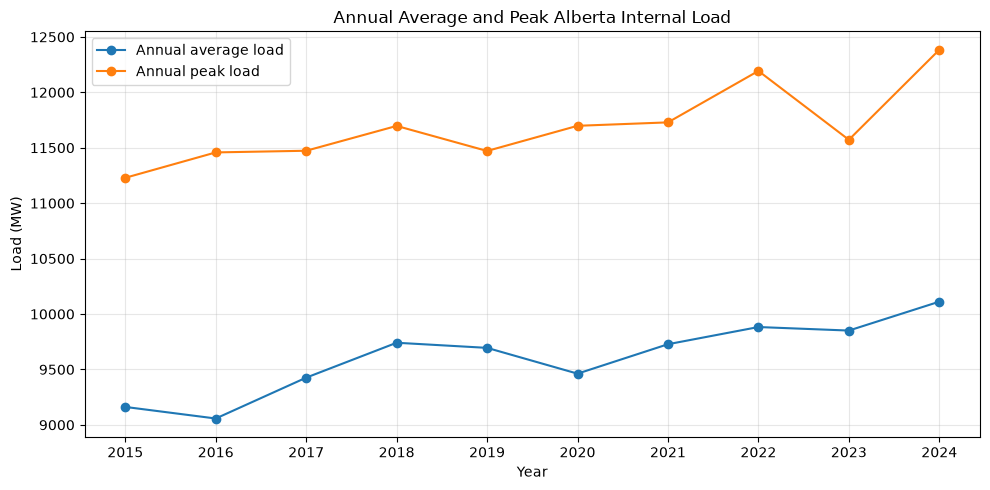

In [11]:
# ---------------------------------------------------------------------
# Visualize long-term demand trends
# ---------------------------------------------------------------------

plot_df = annual_load.copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_df.index,
    plot_df["average_load_mw"],
    marker="o",
    label="Annual average load",
)

ax.plot(
    plot_df.index,
    plot_df["peak_load_mw"],
    marker="o",
    label="Annual peak load",
)

ax.set_title("Annual Average and Peak Alberta Internal Load")
ax.set_xlabel("Year")
ax.set_ylabel("Load (MW)")
ax.set_xticks(plot_df.index)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

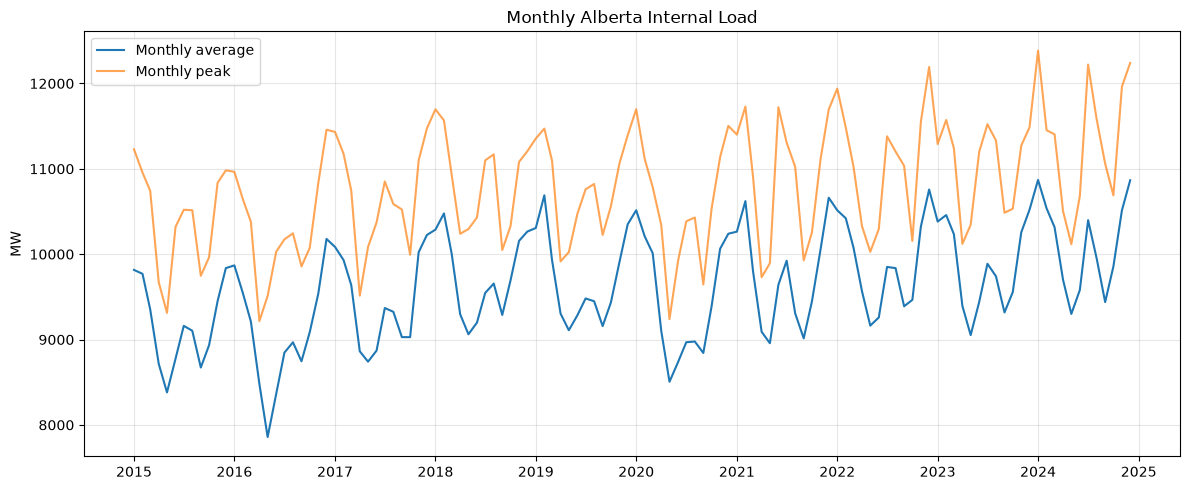

In [12]:
# ---------------------------------------------------------------------
# Visualize monthly demand evolution
# ---------------------------------------------------------------------

monthly_load = (
    master.set_index("timestamp_utc")[load_col]
    .resample("MS")
    .agg(["mean", "max"])
    .rename(
        columns={
            "mean": "average_load_mw",
            "max": "peak_load_mw",
        }
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_load.index,
    monthly_load["average_load_mw"],
    label="Monthly average",
)

ax.plot(
    monthly_load.index,
    monthly_load["peak_load_mw"],
    alpha=0.7,
    label="Monthly peak",
)

ax.set_title("Monthly Alberta Internal Load")
ax.set_xlabel("")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Electricity Demand

Average, peak, and minimum Alberta Internal Load all increased over the 2015–2024 sample, although growth was uneven. The nearly complete 2024 energy total omits seven local-calendar hours; its annual average is largely unaffected.

The monthly profile remains strongly seasonal: winter generally records the highest demand, shoulder seasons the lowest, and recent summers show increasingly important peaks. The data establish these patterns but do not identify their sectoral causes.

### 2.2 How Has the Generation Mix Changed?

In [13]:
# ---------------------------------------------------------------------
# Define generation categories for analysis
# ---------------------------------------------------------------------

GENERATION_COLUMNS = {
    "Coal": "coal_system_generation",
    "Cogeneration": "cogeneration_system_generation",
    "Combined Cycle": "combined_cycle_system_generation",
    "Dual Fuel": "dual_fuel_system_generation",
    "Gas-Fired Steam": "gas_fired_steam_system_generation",
    "Hydro": "hydro_system_generation",
    "Other": "other_system_generation",
    "Simple Cycle": "simple_cycle_system_generation",
    "Solar": "solar_system_generation",
    "Storage": "storage_system_generation",
    "Wind": "wind_system_generation",
}

In [14]:
# ---------------------------------------------------------------------
# Summarize annual generation by fuel category
# ---------------------------------------------------------------------

annual_generation_gwh = (
    master
    .groupby("year_alberta")[list(GENERATION_COLUMNS.values())]
    .sum(min_count=1)
    .div(1_000)
    .rename(
        columns={
            column: fuel
            for fuel, column in GENERATION_COLUMNS.items()
        }
    )
)


display(annual_generation_gwh.round(1))

,Coal,Cogeneration,Combined Cycle,Dual Fuel,Gas-Fired Steam,Hydro,Other,Simple Cycle,Solar,Storage,Wind
year_alberta,,,,,,,,,,,
2015,39392.8,10357.8,5033.8,NaN,NaN,1708.2,570.3,703.8,NaN,NaN,4089.2
2016,38424.0,10427.4,5943.7,NaN,NaN,1733.0,609.1,741.0,NaN,NaN,4405.1
2017,37138.6,10933.4,7246.4,NaN,NaN,1887.2,515.8,888.1,0.1,NaN,4486.3
2018,28523.0,14066.5,9187.4,473.9,NaN,1861.2,651.6,2486.5,22.4,NaN,4104.1
2019,27199.9,14227.0,9652.2,708.6,NaN,1995.6,623.2,2815.2,20.3,NaN,4115.8
2020,20164.0,13795.4,10085.5,2243.3,NaN,2035.3,569.7,2453.8,86.3,0.1,6079.4
2021,15404.8,14321.1,9776.1,2606.6,3616.1,1818.2,697.5,3562.1,477.0,0.6,6132.9
2022,9711.9,13907.8,10703.7,597.9,10509.6,1922.6,651.1,3542.2,1163.9,0.7,7315.3
2023,6519.6,13515.3,10884.4,4038.7,10602.5,1688.8,698.0,2436.1,2311.2,1.8,10283.9


,reported_category_total_gwh,total_system_generation_gwh,difference_pct
year_alberta,,,
2015,61855.87,61855.87,0.0
2016,62283.23,62283.23,0.0
2017,63095.83,63095.83,0.0
2018,61376.55,61376.55,0.0
2019,61357.89,61357.89,-0.0
2020,57512.77,57512.77,0.0
2021,58412.92,58412.92,0.0
2022,60026.74,60026.74,-0.0
2023,62980.17,62980.17,-0.0


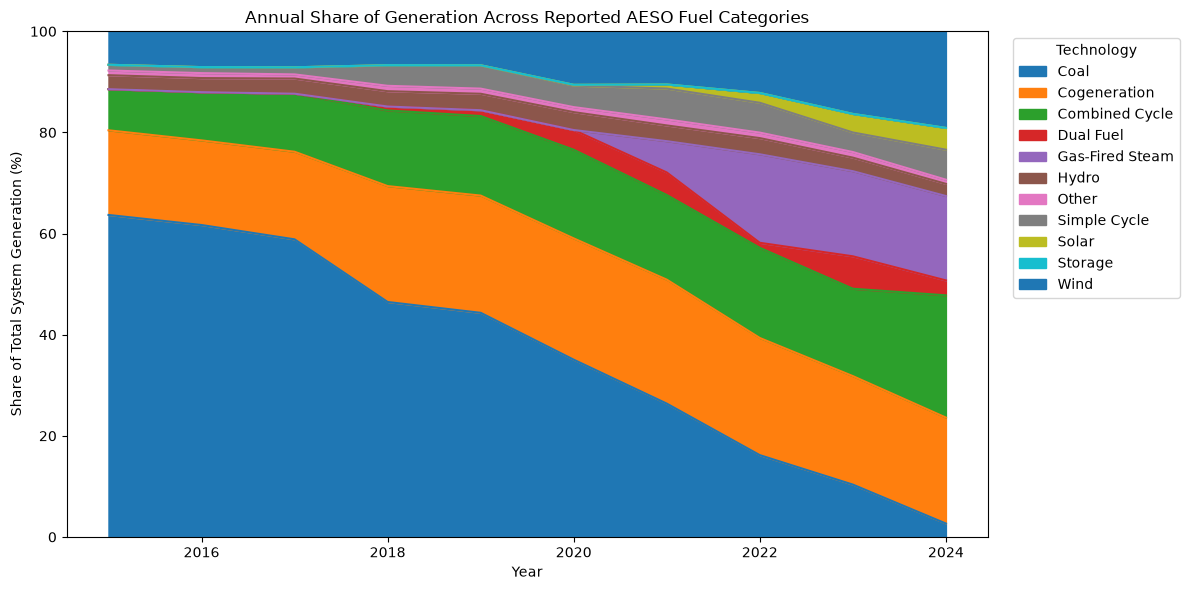

In [15]:
# ---------------------------------------------------------------------
# Reconcile reported categories and visualize annual generation shares
# ---------------------------------------------------------------------

annual_total_system_generation_gwh = (
    master.groupby("year_alberta")["total_system_generation"]
    .sum(min_count=1)
    .div(1_000)
)

generation_reconciliation = pd.DataFrame({
    "reported_category_total_gwh": annual_generation_gwh.sum(axis=1, min_count=1),
    "total_system_generation_gwh": annual_total_system_generation_gwh,
})

generation_reconciliation["difference_pct"] = (
    (
        generation_reconciliation["reported_category_total_gwh"]
        - generation_reconciliation["total_system_generation_gwh"]
    )
    / generation_reconciliation["total_system_generation_gwh"]
    * 100
)

display(generation_reconciliation.round(2))

annual_generation_share = (
    annual_generation_gwh
    .div(annual_total_system_generation_gwh, axis=0)
    .mul(100)
)

annual_generation_share_plot = annual_generation_share.fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

annual_generation_share_plot.plot(
    kind="area",
    stacked=True,
    ax=ax,
)

ax.set_title("Annual Share of Generation Across Reported AESO Fuel Categories")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Total System Generation (%)")
ax.set_ylim(0, 100)
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


#### Generation Mix

Coal fell from roughly two-thirds of total system generation in 2015 to less than 3% in 2024. Alberta replaced dispatchable coal mainly with dispatchable gas while also adding intermittent wind and solar. Annual energy shares therefore describe the transition but not availability during a stressed hour.

> **Reporting note:** AESO classifications changed during the transition. Dual Fuel begins in 2018, Gas-Fired Steam becomes separate in 2021, and Coal and Dual Fuel are later removed or reclassified. Shares use `total_system_generation` as a consistent denominator. For plotting, an unavailable category is shown as zero, meaning no separate AESO category was reported—not necessarily that technically similar generation was physically absent.

### 2.3 How Has Reported Generation Capacity Changed?

AESO **Maximum Capacity** is its broadest reported capability measure. It can include capacity that is unavailable, non-dispatchable, or inaccessible to the grid during a stressed hour, so it is not equivalent to firm capacity.

In [16]:
# ---------------------------------------------------------------------
# Define AESO maximum-capacity variables by technology
# ---------------------------------------------------------------------

CAPACITY_COLUMNS = {
    "Coal": "coal_maximum_capacity",
    "Cogeneration": "cogeneration_maximum_capacity",
    "Combined Cycle": "combined_cycle_maximum_capacity",
    "Simple Cycle": "simple_cycle_maximum_capacity",
    "Gas-Fired Steam": "gas_fired_steam_maximum_capacity",
    "Hydro": "hydro_maximum_capacity",
    "Other": "other_maximum_capacity",
    "Solar": "solar_maximum_capacity",
    "Storage": "storage_maximum_capacity",
    "Wind": "wind_maximum_capacity",
}

TOTAL_MAXIMUM_CAPACITY_COLUMN = "total_maximum_capacity"

In [17]:
# ---------------------------------------------------------------------
# Summarize year-end maximum generation capacity by technology
# ---------------------------------------------------------------------

capacity_columns = [
    *CAPACITY_COLUMNS.values(),
    TOTAL_MAXIMUM_CAPACITY_COLUMN,
]

year_end_capacity = (
    master
    .sort_values("timestamp_utc")
    .groupby("year_alberta", group_keys=False)
    .tail(1)
    .set_index("year_alberta")
)

annual_capacity_mw = (
    year_end_capacity[capacity_columns]
    .rename(
        columns={
            **{
                column: technology
                for technology, column in CAPACITY_COLUMNS.items()
            },
            TOTAL_MAXIMUM_CAPACITY_COLUMN: "Reported Total",
        }
    )
)

display(annual_capacity_mw.round(1))

,Coal,Cogeneration,Combined Cycle,Simple Cycle,Gas-Fired Steam,Hydro,Other,Solar,Storage,Wind,Reported Total
year_alberta,,,,,,,,,,,
2015,6289.0,4552.0,1758.0,946.0,NaN,894.0,386.0,NaN,NaN,1463.0,16288.0
2016,6299.0,4779.0,1745.0,866.0,NaN,894.0,395.0,NaN,NaN,1445.0,16423.0
2017,6003.0,4986.0,1745.0,866.0,NaN,894.0,392.0,15.0,NaN,1445.0,16346.0
2018,5568.0,4987.0,1790.0,871.0,NaN,894.0,381.0,15.0,NaN,1445.0,16106.0
2019,5183.0,5093.0,1790.0,855.0,NaN,894.0,381.0,15.0,NaN,1781.0,16532.0
2020,4132.0,5131.0,1798.0,1076.0,NaN,894.0,381.0,107.0,30.0,1781.0,16270.0
2021,2530.0,5247.0,1798.0,1182.0,1981.0,894.0,382.0,736.0,50.0,2269.0,17224.0
2022,820.0,5285.0,1852.0,1190.0,2609.0,894.0,402.0,1138.0,70.0,3618.0,18344.0
2023,820.0,5304.0,3052.0,909.0,2609.0,894.0,402.0,1650.0,190.0,4481.0,20777.0


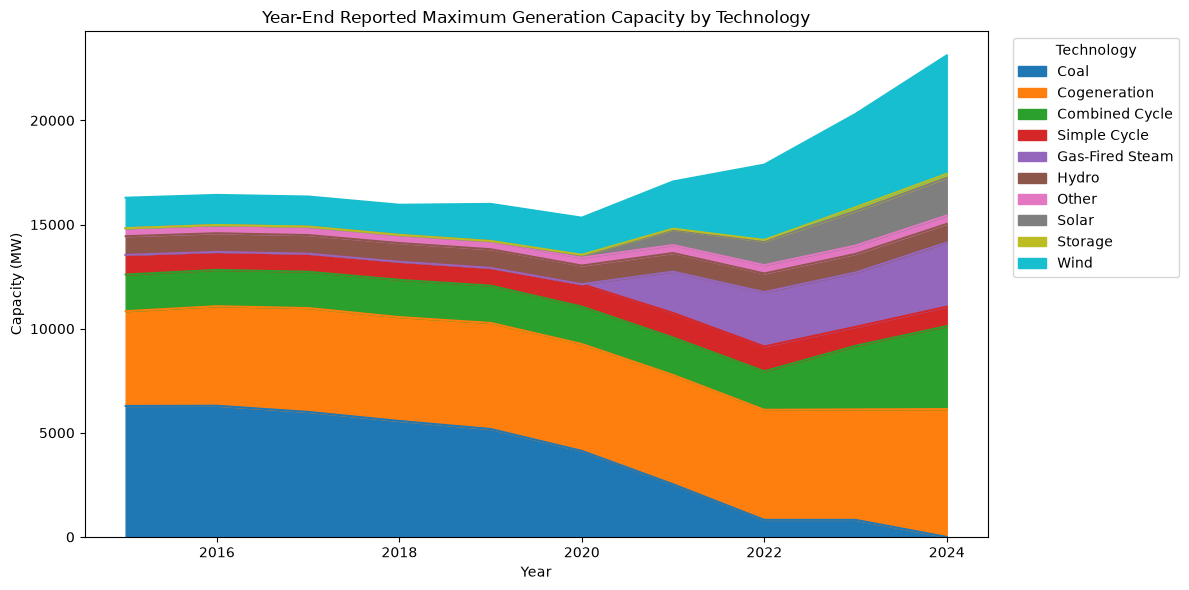

In [18]:
# ---------------------------------------------------------------------
# Visualize changes in maximum generation capacity
# ---------------------------------------------------------------------

technology_columns = list(CAPACITY_COLUMNS.keys())

fig, ax = plt.subplots(figsize=(12, 6))

annual_capacity_mw[technology_columns].plot(
    kind="area",
    stacked=True,
    ax=ax,
)

ax.set_title("Year-End Reported Maximum Generation Capacity by Technology")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity (MW)")
ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

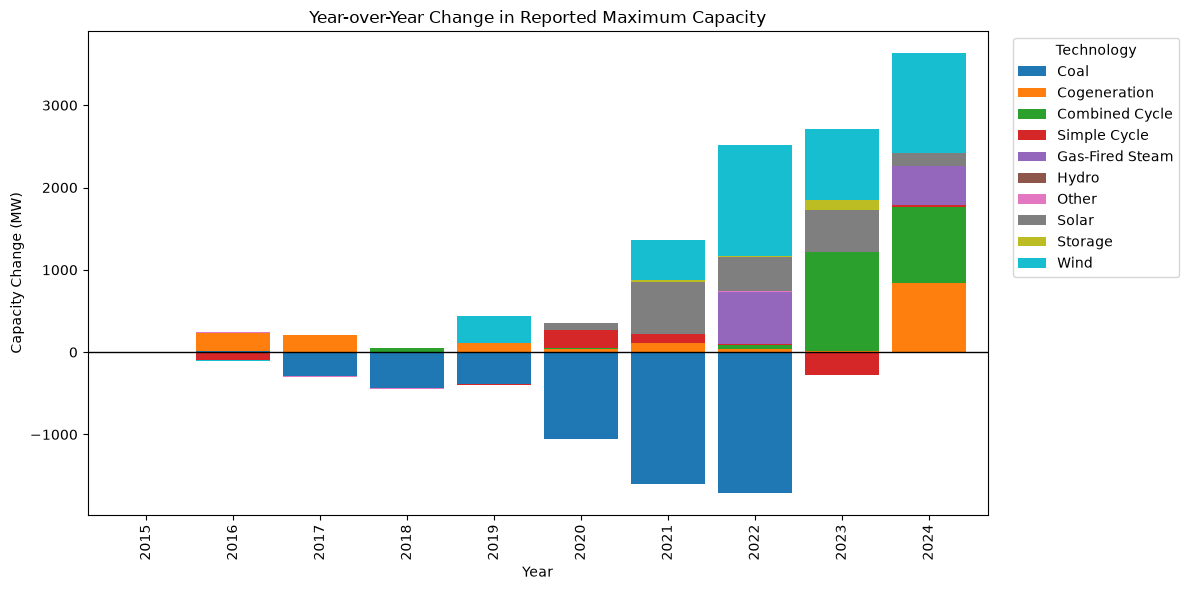

In [19]:
# ---------------------------------------------------------------------
# Visualize year-over-year changes in maximum generation capacity
# ---------------------------------------------------------------------

capacity_change_mw = annual_capacity_mw[
    technology_columns
].diff()

fig, ax = plt.subplots(figsize=(12, 6))

capacity_change_mw.plot(
    kind="bar",
    stacked=True,
    width=0.85,
    ax=ax,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title("Year-over-Year Change in Reported Maximum Capacity")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity Change (MW)")

ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

#### Reported Maximum Generation Capacity

Reported maximum capacity rose from about **16.3 GW** in 2015 to **23.1 GW** in 2024. Coal declined, combined-cycle gas and cogeneration expanded, wind reached about **5.7 GW**, solar about **1.8 GW**, and reported storage about **190 MW**.

Some movements reflect AESO reclassification as well as physical additions or retirements. Gas-Fired Steam, for example, appears separately only from 2021.

The central distinction is that reported maximum capacity is not firm capacity. Wind and solar output depend on conditions; thermal units can be unavailable; behind-the-fence capability may not be fully accessible to the grid; and interties can saturate. Capacity growth alongside more frequent high-price events makes availability, dispatchability, outages, net load, and system margin the relevant next quantities.

### 2.4 How Has Intertie Usage Changed?

In [20]:
# ---------------------------------------------------------------------
# Summarize annual intertie imports and exports
# ---------------------------------------------------------------------

imports_col = "total_imports_mw"
exports_col = "total_exports_mw"
net_imports_col = "net_imports_mw"

annual_interties = (
    master.groupby("year_alberta").agg(
        average_total_imports_mw=(
            imports_col,
            "mean",
        ),
        peak_total_import_mw=(
            imports_col,
            "max",
        ),
        total_import_energy_gwh=(
            imports_col,
            lambda series: series.sum(min_count=1) / 1_000,
        ),
        average_total_exports_mw=(
            exports_col,
            "mean",
        ),
        total_export_energy_gwh=(
            exports_col,
            lambda series: series.sum(min_count=1) / 1_000,
        ),
        average_net_imports_mw=(
            net_imports_col,
            "mean",
        ),
        peak_net_imports_mw=(
            net_imports_col,
            "max",
        ),
        minimum_net_imports_mw=(
            net_imports_col,
            "min",
        ),
        net_importing_hours=(
            "is_net_importing",
            "sum",
        ),
        net_exporting_hours=(
            "is_net_exporting",
            "sum",
        ),
    )
)

annual_interties["net_import_energy_gwh"] = (
    annual_interties["total_import_energy_gwh"]
    - annual_interties["total_export_energy_gwh"]
)

display(annual_interties.round(2))

,average_total_imports_mw,peak_total_import_mw,total_import_energy_gwh,average_total_exports_mw,total_export_energy_gwh,average_net_imports_mw,peak_net_imports_mw,minimum_net_imports_mw,net_importing_hours,net_exporting_hours,net_import_energy_gwh
year_alberta,,,,,,,,,,,
2015,124.57,1002.0,1091.22,74.26,650.55,50.30,1002.0,-877.0,4151,2982,440.67
2016,49.52,769.0,435.02,98.67,866.74,-49.15,729.0,-935.0,2408,3749,-431.72
2017,147.79,998.0,1294.66,116.62,1021.61,31.17,998.0,-935.0,3104,4363,273.05
2018,387.42,1092.0,3393.79,83.40,730.60,304.02,1092.0,-1010.0,6390,1890,2663.19
2019,243.43,1154.0,2132.42,69.65,610.13,173.78,1154.0,-939.0,6368,1765,1522.29
2020,451.45,1118.0,3965.51,11.13,97.80,440.31,1118.0,-332.0,8387,75,3867.71
2021,473.81,1059.0,4150.55,15.01,131.46,458.80,1022.0,-532.0,8550,150,4019.09
2022,484.41,983.0,4243.42,71.95,630.31,412.46,983.0,-939.0,7810,942,3613.11
2023,248.57,888.0,2177.47,247.62,2169.12,0.95,888.0,-1026.0,5243,3466,8.35


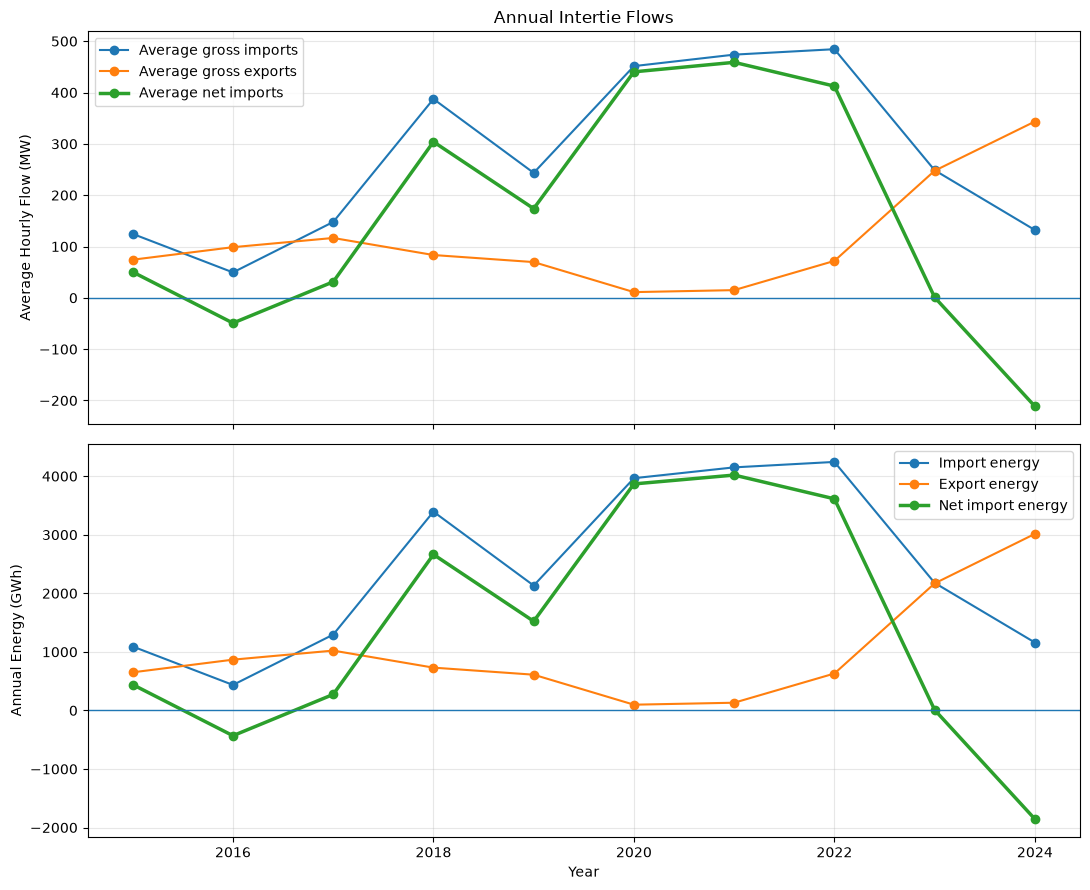

In [21]:
# ---------------------------------------------------------------------
# Visualize annual intertie flows and energy balances
# ---------------------------------------------------------------------

plot_df = annual_interties.copy()

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 9),
    sharex=True,
)

# Average hourly power flows.
axes[0].plot(
    plot_df.index,
    plot_df["average_total_imports_mw"],
    marker="o",
    label="Average gross imports",
)

axes[0].plot(
    plot_df.index,
    plot_df["average_total_exports_mw"],
    marker="o",
    label="Average gross exports",
)

axes[0].plot(
    plot_df.index,
    plot_df["average_net_imports_mw"],
    marker="o",
    linewidth=2.5,
    label="Average net imports",
)

axes[0].axhline(0, linewidth=1)
axes[0].set_title("Annual Intertie Flows")
axes[0].set_ylabel("Average Hourly Flow (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Annual imported, exported, and net energy.
axes[1].plot(
    plot_df.index,
    plot_df["total_import_energy_gwh"],
    marker="o",
    label="Import energy",
)

axes[1].plot(
    plot_df.index,
    plot_df["total_export_energy_gwh"],
    marker="o",
    label="Export energy",
)

axes[1].plot(
    plot_df.index,
    plot_df["net_import_energy_gwh"],
    marker="o",
    linewidth=2.5,
    label="Net import energy",
)

axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Annual Energy (GWh)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------------------------
# Summarize imports relative to Alberta Internal Load
# ---------------------------------------------------------------------

imports_share_of_load = (
    master[imports_col]
    / master[load_col]
    * 100
)

annual_import_share = (
    imports_share_of_load
    .groupby(master["year_alberta"])
    .agg(
        average_import_share_pct="mean",
        median_import_share_pct="median",
        p95_import_share_pct=lambda series: series.quantile(0.95),
    )
)

display(annual_import_share.round(2))

,average_import_share_pct,median_import_share_pct,p95_import_share_pct
year_alberta,,,
2015,1.30,0.47,6.27
2016,0.55,0.00,3.13
2017,1.66,0.00,9.18
2018,4.03,3.16,10.24
2019,2.53,1.66,8.86
2020,4.82,4.17,10.72
2021,4.82,4.70,8.53
2022,4.90,5.06,8.73
2023,2.54,2.16,5.81


#### Intertie Flows

Alberta moved from relatively balanced trade in 2015–2017 to sustained net imports from 2018 through 2022. Net-import energy peaked near **4.0 TWh** in 2021. Trade then shifted: 2023 was nearly balanced, and the nearly complete 2024 sample recorded about **1.9 TWh** of net exports.

Large hourly flows continued in both directions, so annual net trade does not imply one-way use. The shift is consistent with a larger and often more competitive supply stack—including CCGT and renewable additions—but this notebook does not isolate the causes.

Contemporaneous imports may respond to internal stress, external price opportunities, or both. Comparing lagged flows, available transfer capability, and price can distinguish timing and test whether interties saturate during the most severe events.

### 2.5 Section 2 Summary

In [23]:
# ---------------------------------------------------------------------
# Summarize key structural changes over the study period
# ---------------------------------------------------------------------

first_year = 2015
final_year = 2024

section_2_summary = pd.DataFrame({
    "metric": [
        "Average load",
        "Peak load",
        "Annual electricity consumption",
        "Coal share of total system generation",
        "Wind share of total system generation",
        "Reported maximum generation capacity",
        "Average net imports",
        "Net import energy",
    ],
    f"{first_year}": [
        annual_load.loc[first_year, "average_load_mw"],
        annual_load.loc[first_year, "peak_load_mw"],
        annual_load.loc[first_year, "annual_energy_twh"],
        annual_generation_share.loc[first_year, "Coal"],
        annual_generation_share.loc[first_year, "Wind"],
        annual_capacity_mw.loc[first_year, "Reported Total"],
        annual_interties.loc[first_year, "average_net_imports_mw"],
        annual_interties.loc[first_year, "net_import_energy_gwh"],
    ],
    f"{final_year}": [
        annual_load.loc[final_year, "average_load_mw"],
        annual_load.loc[final_year, "peak_load_mw"],
        annual_load.loc[final_year, "annual_energy_twh"],
        annual_generation_share.loc[final_year, "Coal"],
        annual_generation_share.loc[final_year, "Wind"],
        annual_capacity_mw.loc[final_year, "Reported Total"],
        annual_interties.loc[final_year, "average_net_imports_mw"],
        annual_interties.loc[final_year, "net_import_energy_gwh"],
    ],
    "unit": [
        "MW",
        "MW",
        "TWh",
        "%",
        "%",
        "MW",
        "MW",
        "GWh",
    ],
})

section_2_summary["change"] = (
    section_2_summary[str(final_year)]
    - section_2_summary[str(first_year)]
)

display(
    section_2_summary.style.format({
        "2015": "{:,.2f}",
        "2024": "{:,.2f}",
        "change": "{:+,.2f}",
    })
)

,metric,2015,2024,unit,change
0,Average load,"9,161.75","10,111.42",MW,+949.67
1,Peak load,"11,229.00","12,384.00",MW,"+1,155.00"
2,Annual electricity consumption,80.26,88.75,TWh,+8.49
3,Coal share of total system generation,63.68,2.65,%,-61.03
4,Wind share of total system generation,6.61,19.10,%,+12.49
5,Reported maximum generation capacity,"16,288.00","23,122.00",MW,"+6,834.00"
6,Average net imports,50.30,-211.42,MW,-261.72
7,Net import energy,440.67,"-1,855.61",GWh,"-2,296.28"


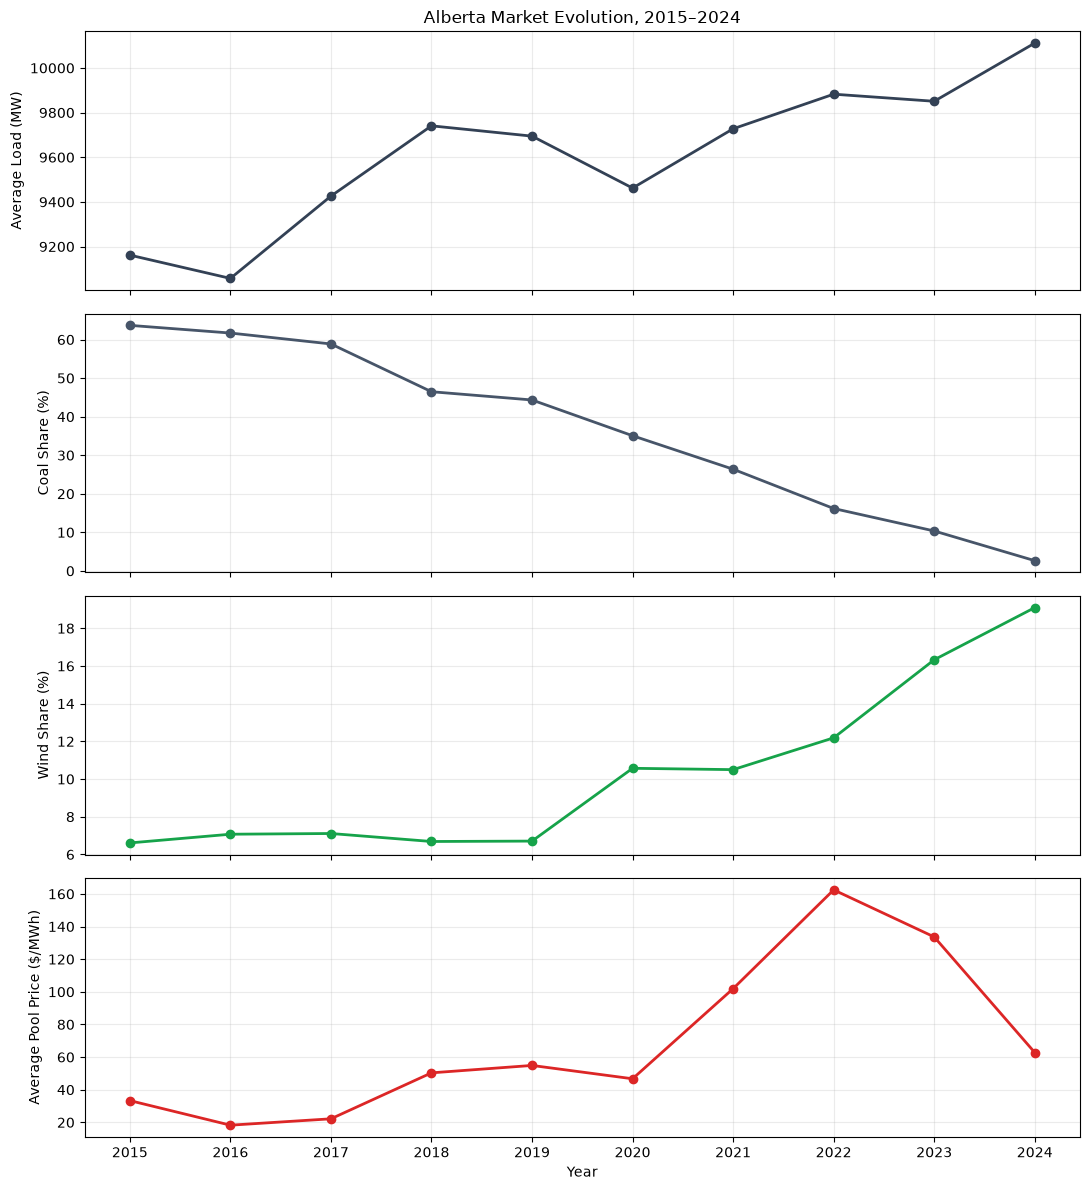

In [24]:
# ---------------------------------------------------------------------
# Summarize Alberta's market evolution in one aligned figure
# ---------------------------------------------------------------------

market_evolution = pd.DataFrame({
    "Average Load (MW)": annual_load["average_load_mw"],
    "Coal Share (%)": annual_generation_share["Coal"],
    "Wind Share (%)": annual_generation_share["Wind"],
    "Average Pool Price ($/MWh)": master.groupby("year_alberta")["pool_price"].mean(),
})

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

colors = ["#334155", "#475569", "#16a34a", "#dc2626"]

for ax, (column, color) in zip(axes, zip(market_evolution.columns, colors)):
    ax.plot(
        market_evolution.index,
        market_evolution[column],
        marker="o",
        linewidth=2,
        color=color,
    )
    ax.set_ylabel(column)
    ax.grid(alpha=0.25)

axes[0].set_title("Alberta Market Evolution, 2015–2024")
axes[-1].set_xlabel("Year")
axes[-1].set_xticks(market_evolution.index)

plt.tight_layout()
plt.show()


#### Section 2 Summary

Between 2015 and 2024, demand rose, coal was replaced by gas and renewables, reported maximum capacity expanded, and Alberta shifted toward net exports. Because reported maximum capacity did not prevent the 2021–2023 high-price regime, the relevant quantity is what was actually available relative to net load.

## Section 3 — What Does a Typical Operating Day Look Like?

Average hourly profiles establish the recurring daily, weekly, and seasonal baseline against which unusual conditions can be compared.

### 3.1 System-Wide Normalized Operating Profile

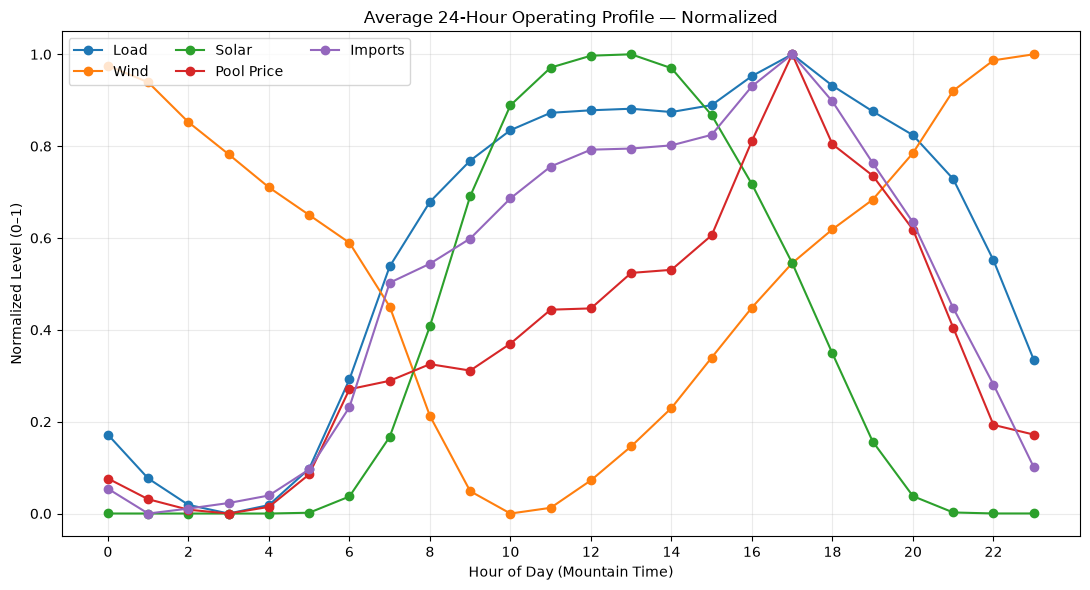

In [25]:
# ---------------------------------------------------------------------
# Compare the average daily shapes of major operating variables
# ---------------------------------------------------------------------

operating_profile_columns = {
    "Load": "ail_mw",
    "Wind": "wind_system_generation",
    "Solar": "solar_system_generation",
    "Pool Price": "pool_price",
    "Imports": "total_imports_mw",
}

average_operating_profile = (
    master.groupby("hour_alberta")[list(operating_profile_columns.values())]
    .mean()
    .rename(columns={value: key for key, value in operating_profile_columns.items()})
)

normalized_operating_profile = (
    (average_operating_profile - average_operating_profile.min())
    / (average_operating_profile.max() - average_operating_profile.min())
)

fig, ax = plt.subplots(figsize=(11, 6))

for column in normalized_operating_profile.columns:
    ax.plot(
        normalized_operating_profile.index,
        normalized_operating_profile[column],
        marker="o",
        label=column,
    )

ax.set_title("Average 24-Hour Operating Profile — Normalized")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Normalized Level (0–1)")
ax.set_xticks(range(0, 24, 2))
ax.legend(ncol=3)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


#### System-Wide Operating Profile

The combined figure highlights the system's daily coordination problem: load, imports, and price rise toward the late-afternoon peak; wind is strongest overnight; and solar peaks around midday. Normalization compares timing rather than magnitude. The mismatch between renewable production and demand motivates net load as a more useful operating-state measure than gross load alone.

### 3.2 Typical Hourly Demand Profile

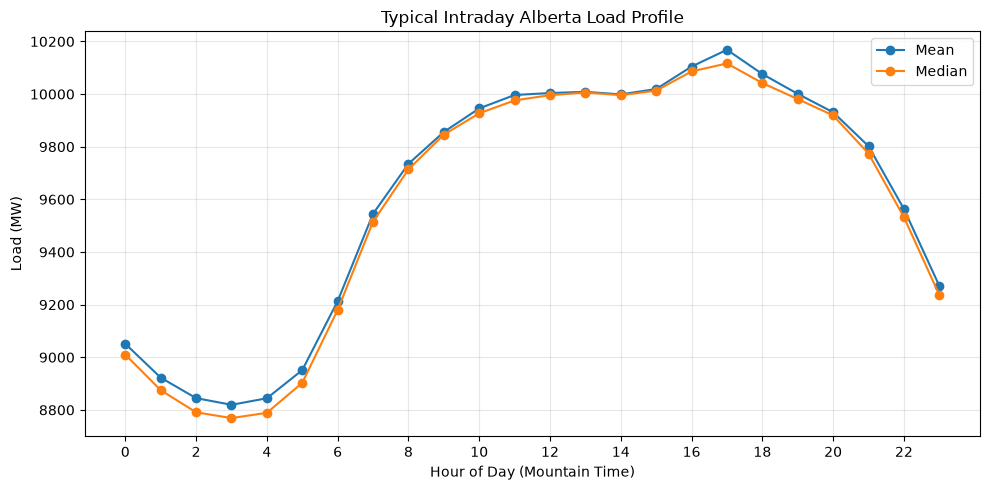

In [26]:
# ---------------------------------------------------------------------
# Summarize the typical hourly Alberta Internal Load profile
# ---------------------------------------------------------------------

hourly_load_profile = (
    master.groupby("hour_alberta")[load_col]
    .agg(["mean", "median"])
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile["mean"],
    marker="o",
    label="Mean",
)

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile["median"],
    marker="o",
    label="Median",
)

ax.set_title("Typical Intraday Alberta Load Profile")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Typical Hourly Demand Profile

Load is lowest around **03:00–04:00**, rises through the morning, and peaks near **17:00**. Similar mean and median profiles indicate that this daily shape is stable, even though individual days can differ materially.

### 3.3 Weekday Versus Weekend Demand

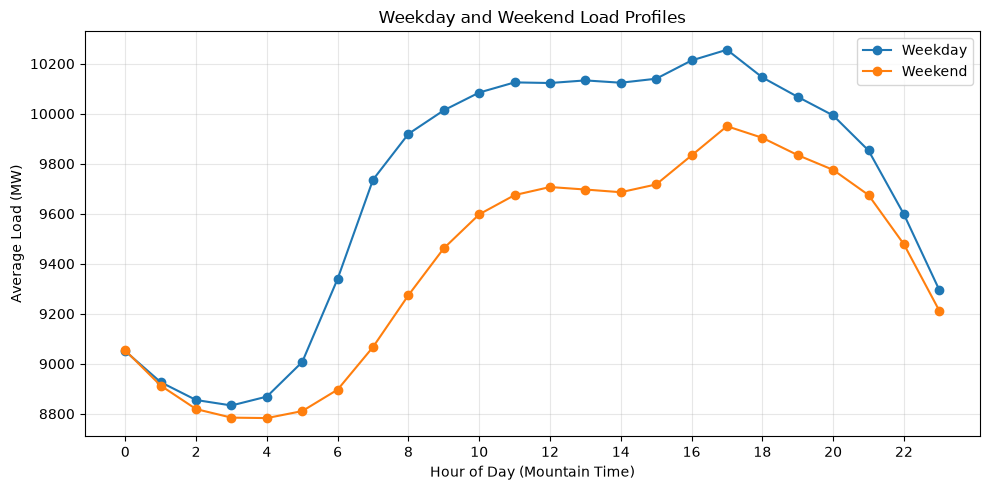

In [27]:
# ---------------------------------------------------------------------
# Compare typical weekday and weekend hourly load profiles
# ---------------------------------------------------------------------

weekday_profile = (
    master.groupby(["hour_alberta", "is_weekend"])[load_col]
    .mean()
    .unstack()
    .rename(
        columns={
            False: "Weekday",
            True: "Weekend",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

for column in weekday_profile.columns:
    ax.plot(
        weekday_profile.index,
        weekday_profile[column],
        marker="o",
        label=column,
    )

ax.set_title("Weekday and Weekend Load Profiles")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Weekday and Weekend Demand Profiles

Weekday and weekend shapes are similar, but weekday demand is higher from roughly **06:00 to 18:00**. The pattern is consistent with greater daytime commercial and industrial activity; the aggregate load data do not directly identify the responsible sectors.

### 3.4 Seasonal Demand Profiles

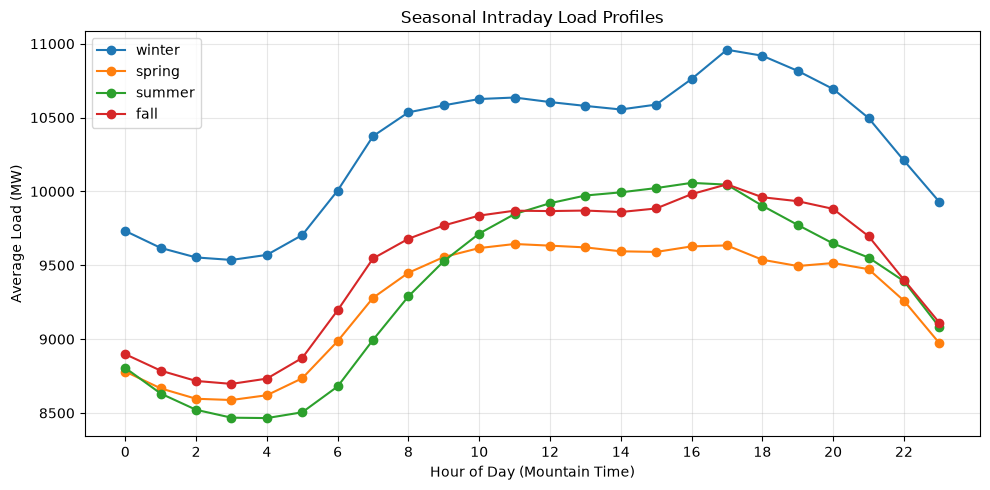

In [28]:
# ---------------------------------------------------------------------
# Compare typical hourly load profiles across seasons
# ---------------------------------------------------------------------

season_order = ["winter", "spring", "summer", "fall"]

seasonal_load_profile = (
    master.groupby(["hour_alberta", "season"])[load_col]
    .mean()
    .unstack()
    .reindex(columns=season_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

for season in seasonal_load_profile.columns:
    ax.plot(
        seasonal_load_profile.index,
        seasonal_load_profile[season],
        marker="o",
        label=season,
    )

ax.set_title("Seasonal Intraday Load Profiles")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Seasonal Demand Profiles

Winter has the highest typical loads and spring the lowest. Every season retains the overnight minimum, morning ramp, and late-afternoon peak. The winter premium is consistent with heating requirements and other seasonal consumption effects.

### 3.5 Typical Price and Import Profiles

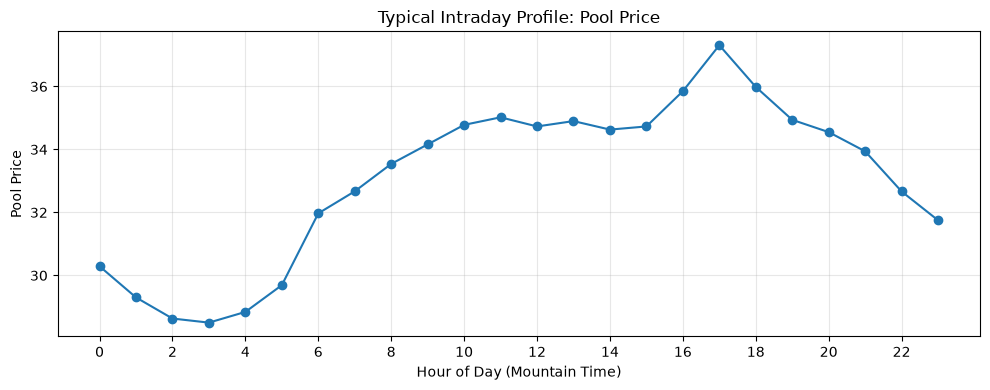

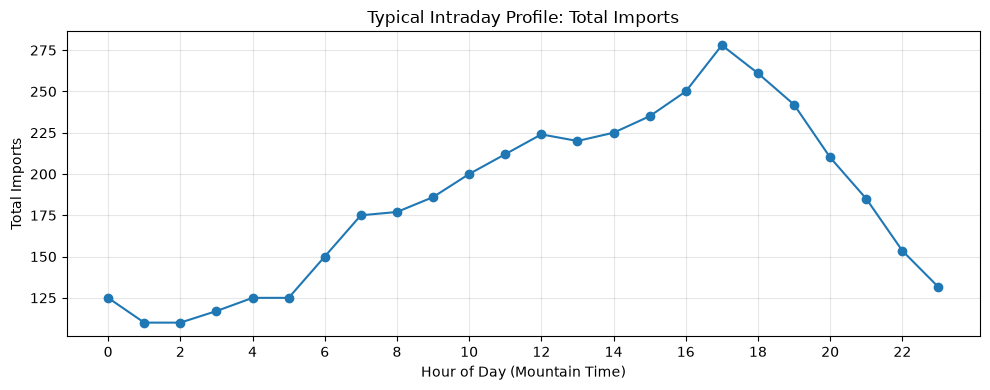

In [29]:
# ---------------------------------------------------------------------
# Compare typical hourly operating profiles for key market variables
# ---------------------------------------------------------------------

profile_variables = {
    "Pool Price": "pool_price",
    "Total Imports": "total_imports_mw",
}

for label, column in profile_variables.items():

    profile = (
        master.groupby("hour_alberta")[column]
        .median()
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        profile.index,
        profile.values,
        marker="o",
    )

    ax.set_title(f"Typical Intraday Profile: {label}")
    ax.set_xlabel("Hour of Day (Mountain Time)")
    ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Typical Price and Import Profiles

Imports and prices rise toward the late-afternoon demand peak. Their similar timing does not establish direction: imports may respond to Alberta stress rather than cause higher prices. Lagged flow and transfer-capability tests can distinguish response from constraint.

### 3.6 Seasonal Solar and Wind Profiles

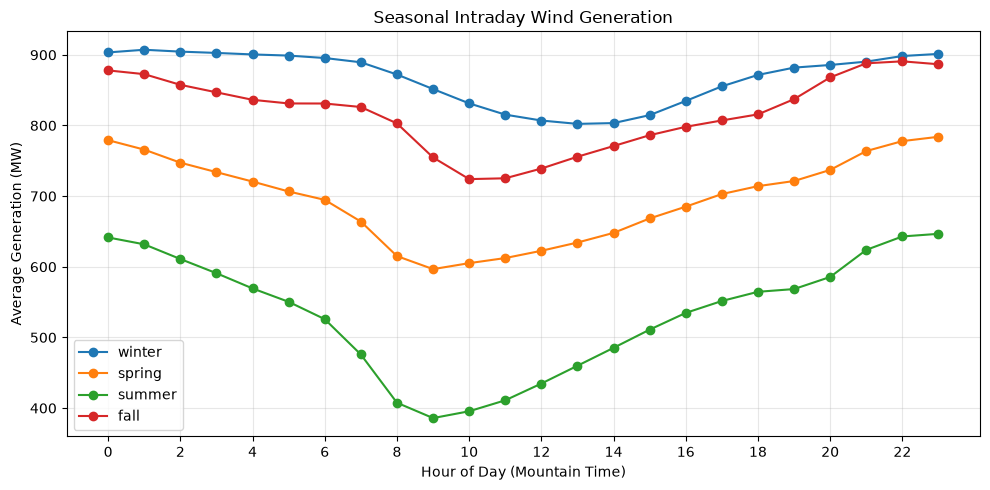

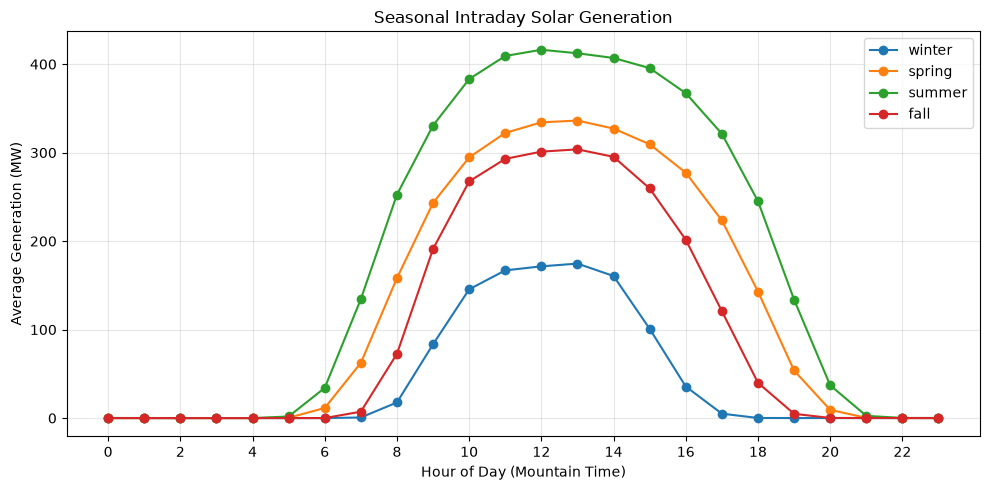

In [30]:
# ---------------------------------------------------------------------
# Compare seasonal hourly wind and solar generation profiles
# ---------------------------------------------------------------------

solar_col = "solar_system_generation"

for label, column in {
    "Wind": "wind_system_generation",
    "Solar": solar_col,
}.items():

    seasonal_profile = (
        master.groupby(["hour_alberta", "season"])[column]
        .mean()
        .unstack()
        .reindex(columns=season_order)
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for season in seasonal_profile.columns:
        ax.plot(
            seasonal_profile.index,
            seasonal_profile[season],
            marker="o",
            label=season,
        )

    ax.set_title(f"Seasonal Intraday {label} Generation")
    ax.set_xlabel("Hour of Day (Mountain Time)")
    ax.set_ylabel("Average Generation (MW)")
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Seasonal Wind and Solar Generation Profiles

Wind is generally strongest in winter and weakest in summer. Solar output is largest around midday and during summer, whereas Alberta's highest demand often occurs in winter and late afternoon. This seasonal and intraday mismatch reinforces the use of net load rather than gross load.

Because installed renewable capacity grew substantially, a more informative specification uses output relative to capacity and interactions with season, hour, load, and concurrent production.

## Section 4 — How Variable Is the Market?

Average profiles conceal skewed prices and infrequent extreme conditions. This section summarizes distributions and high-price tails before examining their timing.

### 4.1 Distribution Summary

In [31]:
# ---------------------------------------------------------------------
# Summarize the distributions of major market variables
# ---------------------------------------------------------------------

distribution_columns = {
    "Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

distribution_summary = pd.DataFrame({
    label: master[column].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    for label, column in distribution_columns.items()
}).T

distribution_summary.columns = [
    "p01",
    "p05",
    "p25",
    "median",
    "p75",
    "p95",
    "p99",
]

display(distribution_summary.round(3))

,p01,p05,p25,median,p75,p95,p99
Load,7740.000,8199.000,9024.000,9616.000,10226.000,10979.000,11402.000
Pool Price,4.596,13.620,21.350,33.230,55.100,259.960,781.125
AECO Gas,0.000,0.500,1.700,2.350,2.770,5.300,7.050
Spark Spread,-8.295,-3.285,6.395,18.715,33.915,233.727,758.258
Net Imports,-920.000,-561.000,-50.000,125.000,450.000,835.000,951.000
Total Imports,0.000,0.000,30.000,180.000,460.000,845.000,953.000
Total Exports,0.000,0.000,0.000,0.000,125.000,635.000,960.000
Total Outages,2147.300,2397.300,2981.400,3440.300,3921.300,4744.400,5636.240


#### Distribution Summary

Load and outages occupy comparatively narrow physical ranges. Pool price and spark spread are strongly right-skewed: their upper quantiles sit far above their medians. Intertie flows are also asymmetric and span both importing and exporting conditions.

These shapes support quantile, regime, and event-based analysis rather than reliance on averages alone.

### 4.2 Histograms

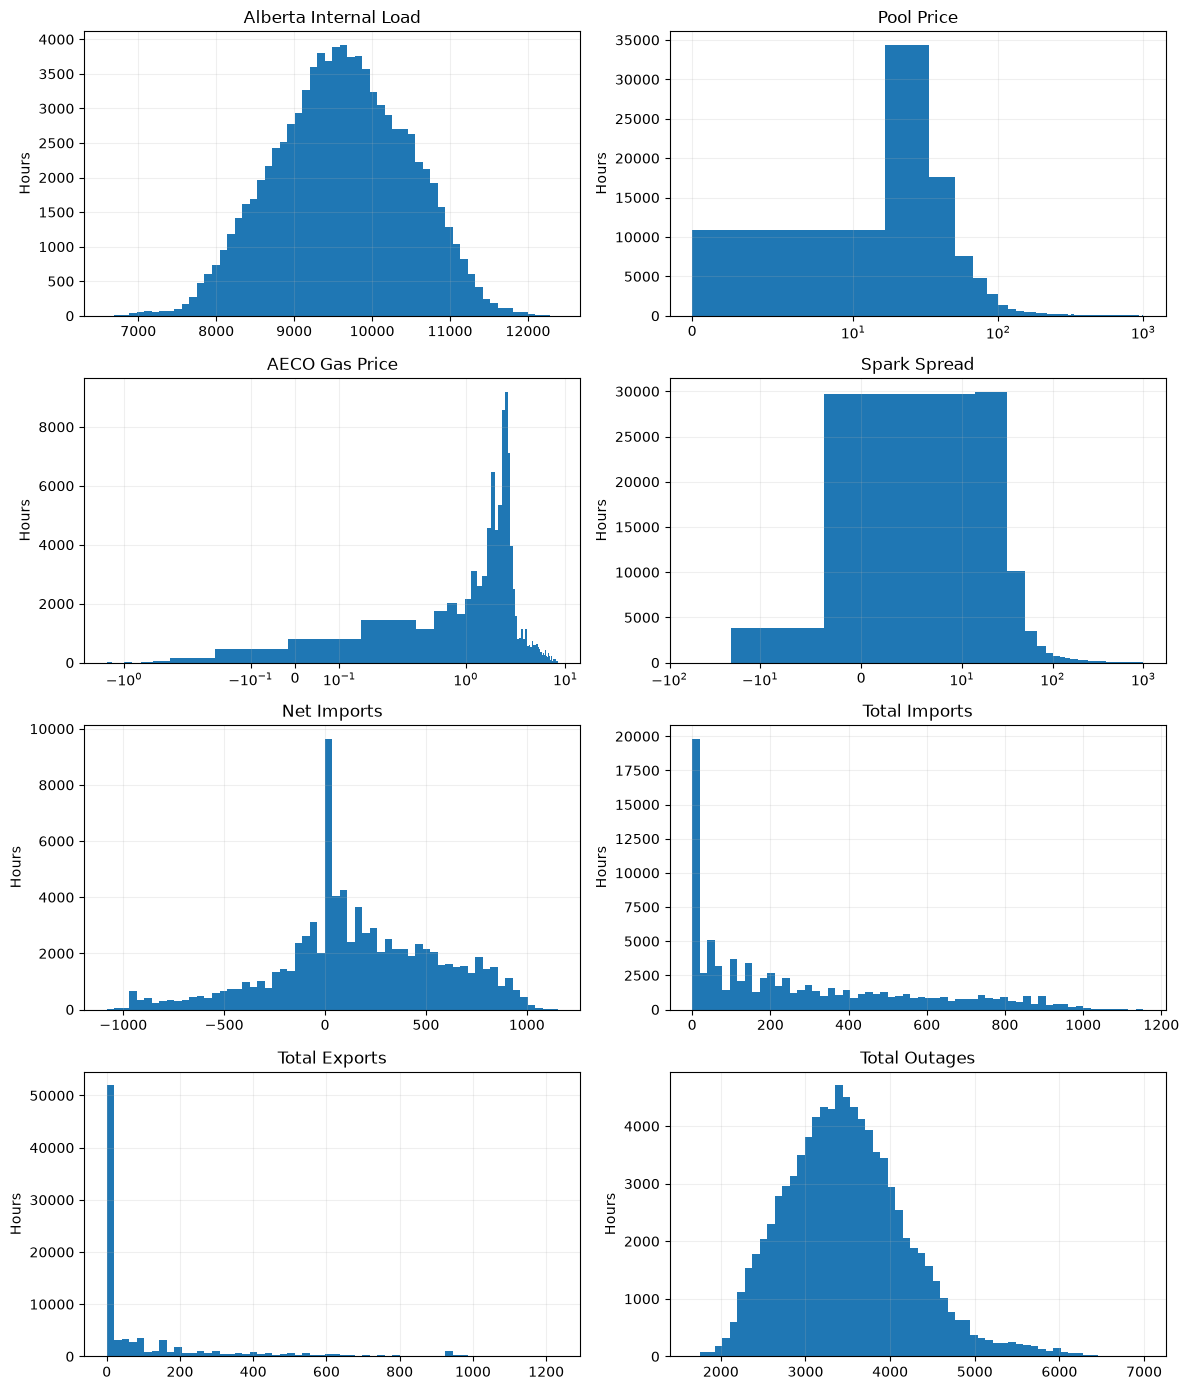

In [32]:
# ---------------------------------------------------------------------
# Visualize major market-variable distributions in a compact panel
# ---------------------------------------------------------------------

histogram_variables = {
    "Alberta Internal Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas Price": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

symmetric_log_thresholds = {
    "Pool Price": 10,
    "Spark Spread": 10,
    "AECO Gas Price": 0.25,
}

fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for ax, (title, column) in zip(axes.flat, histogram_variables.items()):
    ax.hist(master[column].dropna(), bins=60)
    if title in symmetric_log_thresholds:
        ax.set_xscale(
            "symlog",
            linthresh=symmetric_log_thresholds[title],
        )
    ax.set_title(title)
    ax.set_ylabel("Hours")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


#### Distribution Characteristics

Load is comparatively concentrated, while pool price and spark spread have long right tails. Gas prices are moderately skewed; imports and especially exports are concentrated at lower values with occasional large flows.

Pool price, spark spread, and gas use symmetric-log x-axes so their central mass and signed tails remain visible. The contrast between stable physical quantities and volatile economic outcomes suggests threshold behaviour; a key test is whether AECO gas matters primarily when gas prices or net load are already high.

### 4.3 Price Exceedance Frequency

In [33]:
# ---------------------------------------------------------------------
# Summarize pool-price exceedance frequencies
# ---------------------------------------------------------------------

price_thresholds = [0, 100, 200, 500, 900]

price_exceedance = pd.DataFrame({
    "threshold": price_thresholds,
    "hours_at_or_above": [
        master["pool_price"].ge(threshold).sum()
        for threshold in price_thresholds
    ],
    "share_of_hours_pct": [
        master["pool_price"].ge(threshold).mean() * 100
        for threshold in price_thresholds
    ],
})

display(price_exceedance.round(3))


,threshold,hours_at_or_above,share_of_hours_pct
0,0,87665,100.000
1,100,9605,10.956
2,200,5411,6.172
3,500,2292,2.614
4,900,378,0.431


In [34]:
# ---------------------------------------------------------------------
# Summarize annual pool-price regimes without modifying master
# ---------------------------------------------------------------------

price_col = "pool_price"

price_regime_flags = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    price_col: master[price_col],
    "above_100": master[price_col].ge(100),
    "above_200": master[price_col].ge(200),
    "above_500": master[price_col].ge(500),
    "at_or_above_900": master[price_col].ge(900),
    "negative_price": master[price_col].lt(0),
})

annual_price_extremes = (
    price_regime_flags
    .groupby("year_alberta")
    .agg(
        average_price=(price_col, "mean"),
        median_price=(price_col, "median"),
        price_volatility=(price_col, "std"),
        hours_above_100=("above_100", "sum"),
        hours_above_200=("above_200", "sum"),
        hours_above_500=("above_500", "sum"),
        hours_at_or_above_900=("at_or_above_900", "sum"),
        negative_price_hours=("negative_price", "sum"),
    )
)

display(annual_price_extremes.round(2))


,average_price,median_price,price_volatility,hours_above_100,hours_above_200,hours_above_500,hours_at_or_above_900,negative_price_hours
year_alberta,,,,,,,,
2015,33.34,20.48,86.51,196,144,95,28,0
2016,18.28,15.46,12.63,8,4,2,0,0
2017,22.19,19.46,26.96,26,17,6,4,0
2018,50.35,33.25,87.22,361,208,102,29,0
2019,54.88,33.51,90.39,442,264,116,17,0
2020,46.72,33.28,92.13,306,189,102,40,0
2021,101.93,57.34,138.96,1651,871,310,42,0
2022,162.46,83.78,199.22,3179,1663,758,111,0
2023,133.63,57.20,183.84,2446,1547,606,52,0


#### Price Distribution and High-Price Events

Prices were at least **$100/MWh** during about 10% of observations and at least **$500/MWh** during about 2.5%. Events at or above **$900/MWh** were rare.

The annual table separates several regimes. Prices and high-price-event frequencies were especially low during 2016 and 2017. Although the 2015 average was also relatively low, its **$86.51/MWh** standard deviation and **95 hours at or above $500/MWh** distinguish it from the unusually quiet following two years. Prices and volatility increased during 2018–2020, entered a sustained high-price regime in 2021–2023, and moderated in 2024. In 2022, average price reached about **$162/MWh** and annual standard deviation about **$199/MWh**.

Growing renewables and reported maximum capacity did not prevent this regime. Candidate explanations include fuel costs, availability, outages, net load, market rules, and their interactions; none is established here.

## Section 5 — When Is the Market Stressed?

This project uses a high-price threshold to describe when market stress occurs by year, month, and hour.

### 5.1 High-Price Definition and Base Rate

In [35]:
# ---------------------------------------------------------------------
# Confirm the high-price definition and overall event frequency
# ---------------------------------------------------------------------

high_price_event = master[price_col].ge(200).rename("high_price_event")

high_price_summary = pd.Series({
    "total_hours": len(master),
    "high_price_hours": high_price_event.sum(),
    "high_price_rate_pct": high_price_event.mean() * 100,
})

display(high_price_summary.round(2))


total_hours            87665.00
high_price_hours        5411.00
high_price_rate_pct        6.17
dtype: float64

In [36]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by calendar year
# ---------------------------------------------------------------------

high_price_by_year = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("year_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
    )
)

high_price_by_year["high_price_rate_pct"] = high_price_by_year["high_price_rate"] * 100

display(high_price_by_year.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,high_price_rate_pct
year_alberta,,,,,
2015,8760,144,0.016,33.338,1.644
2016,8784,4,0.000,18.279,0.046
2017,8760,17,0.002,22.186,0.194
2018,8760,208,0.024,50.348,2.374
2019,8760,264,0.030,54.880,3.014
2020,8784,189,0.022,46.716,2.152
2021,8760,871,0.099,101.932,9.943
2022,8760,1663,0.190,162.463,18.984
2023,8760,1547,0.177,133.628,17.660


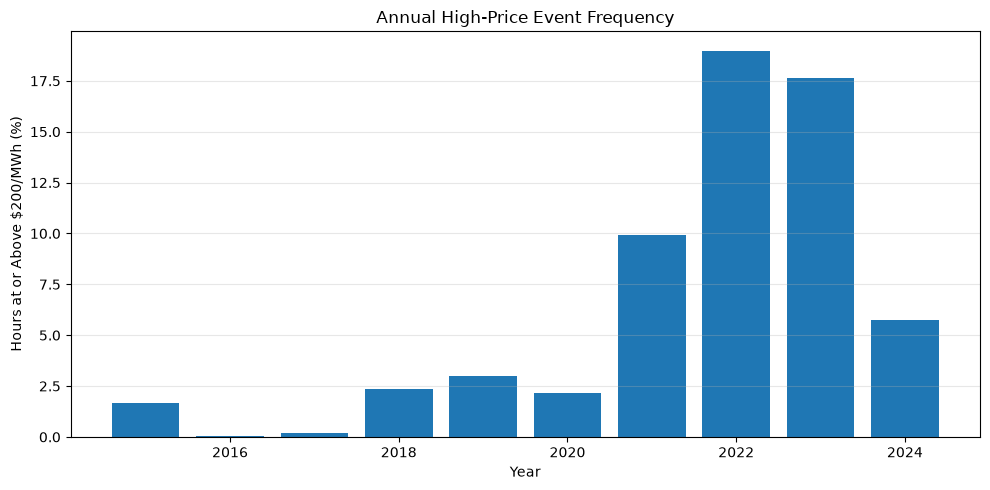

In [37]:
# ---------------------------------------------------------------------
# Visualize annual high-price frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    high_price_by_year.index,
    high_price_by_year["high_price_rate_pct"],
)

ax.set_title("Annual High-Price Event Frequency")
ax.set_xlabel("Year")
ax.set_ylabel("Hours at or Above $200/MWh (%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### High-Price Definition and Base Rate

An hour is labelled **high price** when pool price is at least **$200/MWh**. The project may use "scarcity" as shorthand, but this is a price-defined market-stress state—not a direct observation of reserve deficiency, physical shortage, or involuntary curtailment.

High-price events were uncommon before 2021, increased sharply during 2021–2023, and moderated in 2024. The 2024 rate uses 8,777 observed hours.

### 5.2 High-Price Events by Month

In [38]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by calendar month
# ---------------------------------------------------------------------

month_order = [
    "january", "february", "march", "april",
    "may", "june", "july", "august",
    "september", "october", "november", "december",
]

high_price_by_month = (
    pd.DataFrame({
        "month_name_alberta": master["month_name_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("month_name_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
    )
    .reindex(month_order)
)

high_price_by_month["high_price_rate_pct"] = high_price_by_month["high_price_rate"] * 100

display(high_price_by_month.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,high_price_rate_pct
month_name_alberta,,,,,
january,7440,445,0.060,72.209,5.981
february,6792,436,0.064,70.791,6.419
march,7430,344,0.046,57.597,4.630
april,7200,341,0.047,57.961,4.736
may,7440,432,0.058,65.150,5.806
june,7200,539,0.075,76.716,7.486
july,7440,564,0.076,73.116,7.581
august,7440,585,0.079,79.289,7.863
september,7200,464,0.064,70.265,6.444


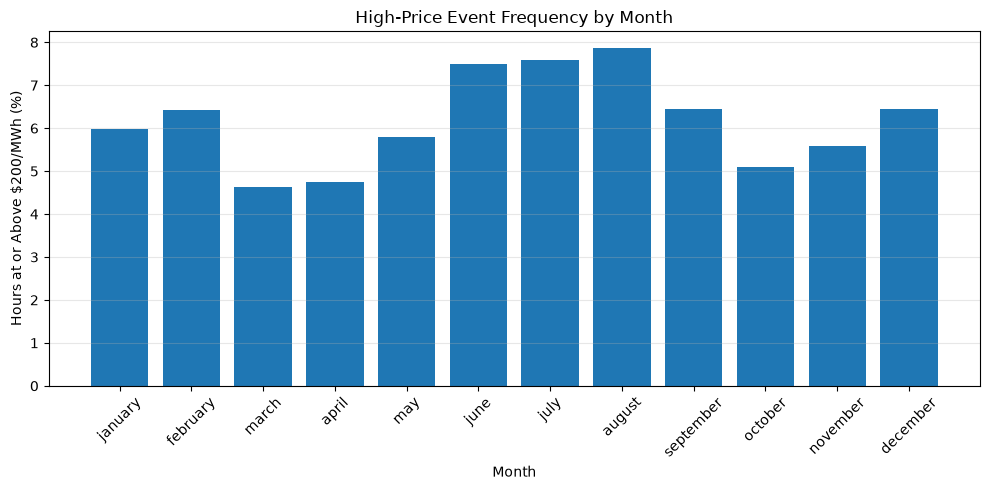

In [39]:
# ---------------------------------------------------------------------
# Visualize seasonal patterns in high-price frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    high_price_by_month.index,
    high_price_by_month["high_price_rate_pct"],
)

ax.set_title("High-Price Event Frequency by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Hours at or Above $200/MWh (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### High-Price Events by Month

Pooling all years, high-price events occur most frequently during summer and are also elevated during winter. The year-month heatmap shows that this seasonal result is partly influenced by the concentration of the 2021–2023 high-price regime. A month-plus-year specification can test whether the monthly relationship remains after controlling for regime, and whether summer and winter stress arise from different combinations of temperature, load, outages, wind, and imports.

### 5.3 High-Price Events by Hour

In [40]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by hour of day
# ---------------------------------------------------------------------

high_price_by_hour = (
    pd.DataFrame({
        "hour_alberta": master["hour_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("hour_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
    )
)

high_price_by_hour["high_price_rate_pct"] = high_price_by_hour["high_price_rate"] * 100

display(high_price_by_hour.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,median_price,high_price_rate_pct
hour_alberta,,,,,,
0,3653,79,0.022,43.782,30.290,2.163
1,3663,56,0.015,40.070,29.300,1.529
2,3643,41,0.011,38.187,28.630,1.125
3,3653,32,0.009,37.500,28.500,0.876
4,3653,51,0.014,38.694,28.840,1.396
5,3653,89,0.024,44.520,29.690,2.436
6,3653,193,0.053,59.793,31.970,5.283
7,3653,185,0.051,61.305,32.670,5.064
8,3653,199,0.054,64.292,33.540,5.448


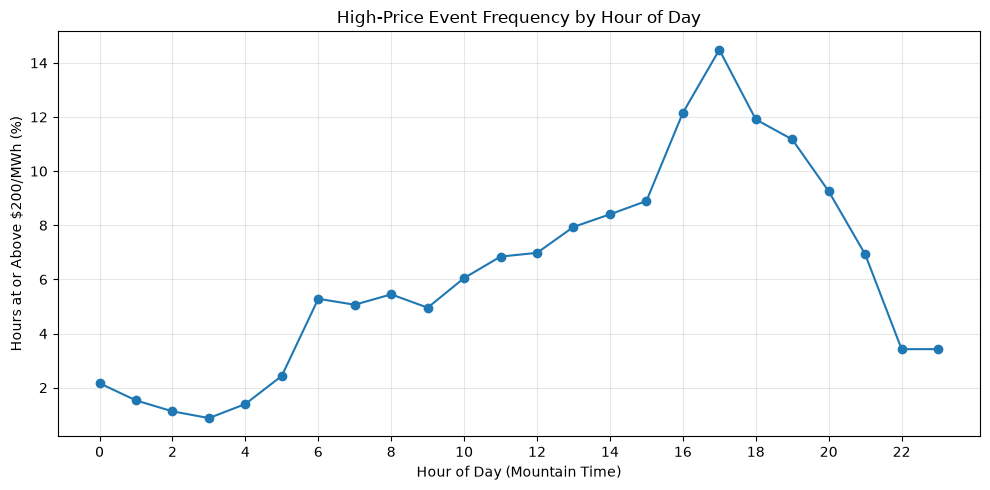

In [41]:
# ---------------------------------------------------------------------
# Visualize the intraday distribution of high-price events
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    high_price_by_hour.index,
    high_price_by_hour["high_price_rate_pct"],
    marker="o",
)

ax.set_title("High-Price Event Frequency by Hour of Day")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Hours at or Above $200/MWh (%)")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### High-Price Events by Hour

The rate is lowest overnight, rises through the day, and peaks near **17:00** with the late-afternoon demand peak. This timing motivates testing whether net load and available system margin explain high prices better than gross load alone.

### 5.4 Year-Month Stress Map

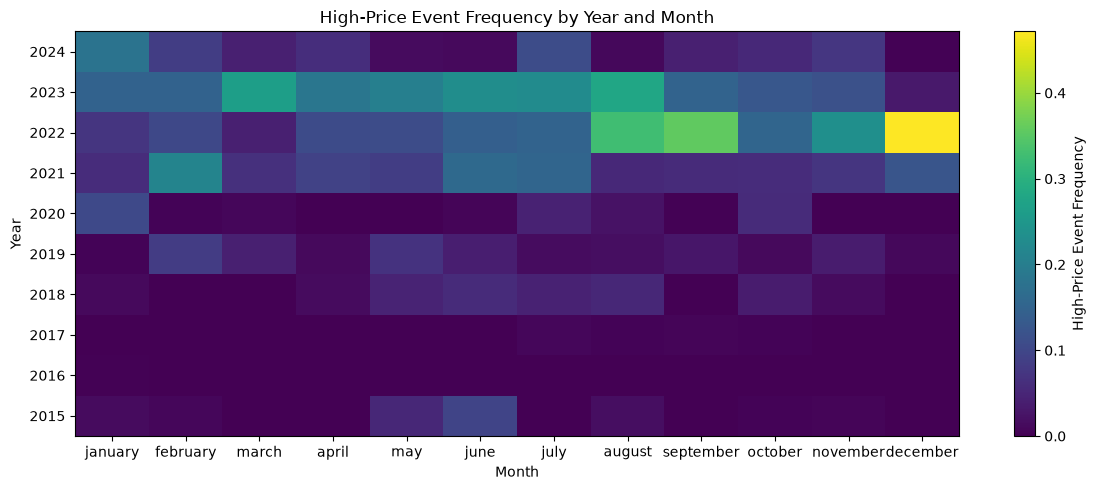

In [42]:
# ---------------------------------------------------------------------
# Visualize the monthly evolution of high-price frequency
# ---------------------------------------------------------------------

high_price_calendar = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "month_alberta": master["month_alberta"],
        "high_price_event": high_price_event,
    })
    .groupby(["year_alberta", "month_alberta"])["high_price_event"]
    .mean()
    .unstack()
    .reindex(columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(high_price_calendar, aspect="auto", origin="lower")
ax.set_title("High-Price Event Frequency by Year and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_xticks(range(12))
ax.set_xticklabels(month_order)
ax.set_yticks(range(len(high_price_calendar.index)))
ax.set_yticklabels(high_price_calendar.index)
plt.colorbar(image, ax=ax, label="High-Price Event Frequency")

plt.tight_layout()
plt.show()


In [43]:
# ---------------------------------------------------------------------
# Display monthly high-price frequency by year
# ---------------------------------------------------------------------

high_price_calendar_pct = (
    high_price_calendar * 100
)

high_price_calendar_pct.columns = month_order

display(high_price_calendar_pct.round(2))

,january,february,march,april,may,june,july,august,september,october,november,december
year_alberta,,,,,,,,,,,,
2015,1.34,0.74,0.00,0.00,5.24,9.58,0.13,1.75,0.00,0.40,0.55,0.00
2016,0.27,0.00,0.00,0.00,0.00,0.00,0.13,0.13,0.00,0.00,0.00,0.00
2017,0.00,0.00,0.00,0.00,0.00,0.00,0.81,0.40,0.56,0.40,0.14,0.00
2018,1.21,0.00,0.00,1.39,4.70,5.83,4.57,5.24,0.14,3.63,1.39,0.13
2019,0.40,8.33,4.17,1.11,6.85,4.03,1.48,1.75,2.78,1.21,3.61,0.94
2020,10.48,0.43,0.81,0.00,0.00,0.69,4.44,2.28,0.28,5.78,0.14,0.13
2021,6.05,21.28,6.59,9.31,8.60,16.11,15.32,5.38,5.83,6.05,7.35,12.50
2022,7.26,10.27,4.17,10.69,11.02,14.31,15.05,32.66,35.69,15.46,23.44,47.18
2023,14.92,14.88,26.38,18.61,20.30,23.06,22.85,27.96,15.00,12.77,11.65,3.23


#### Monthly Evolution of High-Price Events

The heatmap shows clustered regimes rather than independent events. High-price months were isolated before 2021, persistent through 2021–2023, and less frequent in 2024. December 2022 was the most severe month, with nearly half of its hours at or above $200/MWh.

Persistence across consecutive months suggests common regime-level conditions such as fuel costs, availability, outages, or sustained net load. Time-aware validation and explicit regime features are therefore preferable to treating hours as independent.

## Section 6 — What Relationships Stand Out?

These summaries examine contemporaneous relationships only. They identify potentially informative variables but do not evaluate forecasting performance. Predictive testing begins in the next notebook using lagged features and time-based validation.

### 6.1 Correlation Table

**Pearson correlation** summarizes linear association; **Spearman correlation** summarizes monotonic rank association.

In [44]:
# ---------------------------------------------------------------------
# Construct analysis-only relationship variables without modifying master
# ---------------------------------------------------------------------

first_solar_reported = master.loc[
    master["solar_system_generation"].notna(),
    "timestamp_utc",
].min()

solar_generation_for_analysis = (
    master["solar_system_generation"]
    .where(master["timestamp_utc"].ge(first_solar_reported), 0.0)
    .rename("solar_for_analysis")
)

net_load_for_analysis = (
    master["ail_mw"]
    - master["wind_system_generation"]
    - solar_generation_for_analysis
).rename("net_load")

relationship_df = pd.DataFrame({
    "price": master["pool_price"],
    "load": master["ail_mw"],
    "net_load": net_load_for_analysis,
    "wind": master["wind_system_generation"],
    "solar": solar_generation_for_analysis,
    "hydro": master["hydro_system_generation"],
    "total_generation": master["total_system_generation"],
    "imports": master["total_imports_mw"],
    "outages": master["total_outage_mw"],
    "gas": master["gas_price"],
})

relationship_df["renewable_share"] = (
    (
        relationship_df["wind"]
        + relationship_df["solar"]
        + relationship_df["hydro"]
    )
    / relationship_df["total_generation"]
)

relationship_df = relationship_df[
    [
        "price", "load", "net_load", "wind",
        "renewable_share", "imports", "outages", "gas",
    ]
]

relationship_variable_audit = pd.Series({
    "first_solar_reported": first_solar_reported,
    "pre_reporting_solar_hours_set_to_zero": int(
        master["timestamp_utc"].lt(first_solar_reported).sum()
    ),
    "net_load_missing_hours": int(net_load_for_analysis.isna().sum()),
    "master_columns_added": 0,
})

display(relationship_variable_audit.to_frame("value"))

pearson_corr = relationship_df.corr(method="pearson")
spearman_corr = relationship_df.corr(method="spearman")

print("Pearson correlation with price:")
display(pearson_corr["price"].sort_values(ascending=False).to_frame("pearson"))

print("Spearman correlation with price:")
display(spearman_corr["price"].sort_values(ascending=False).to_frame("spearman"))


,value
first_solar_reported,2017-12-05 07:00:00+00:00
pre_reporting_solar_hours_set_to_zero,25656
net_load_missing_hours,0
master_columns_added,0


Pearson correlation with price:


,pearson
price,1.000000
net_load,0.306846
load,0.260430
gas,0.250029
imports,0.243115
outages,0.116812
renewable_share,-0.106956
wind,-0.169682


Spearman correlation with price:


,spearman
price,1.000000
imports,0.497703
load,0.438992
net_load,0.432942
gas,0.391449
outages,0.100029
renewable_share,-0.037533
wind,-0.130323


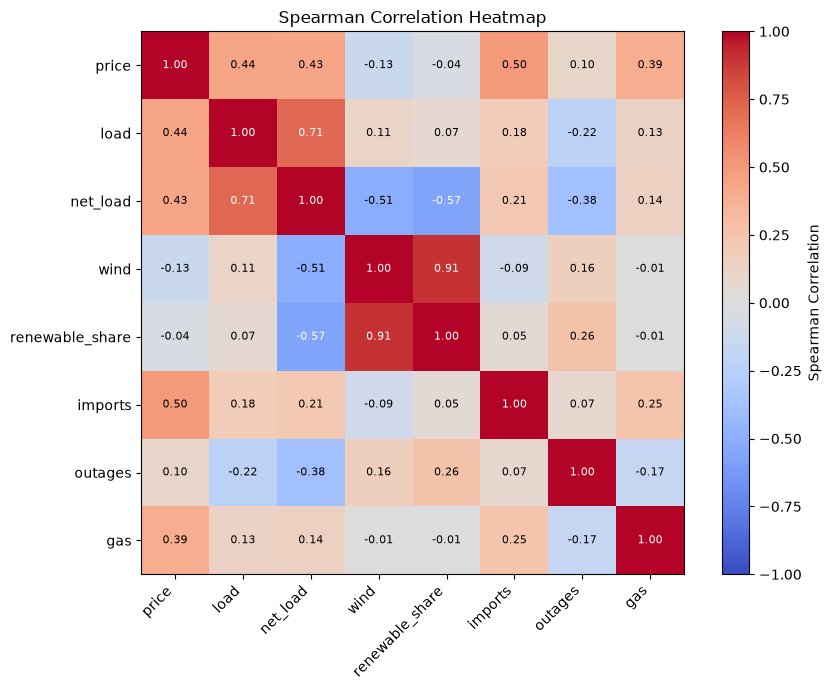

In [45]:
# ---------------------------------------------------------------------
# Visualize monotonic relationships among selected variables
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    spearman_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_title("Spearman Correlation Heatmap")
ax.set_xticks(range(len(spearman_corr.columns)))
ax.set_xticklabels(spearman_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(spearman_corr.index)))
ax.set_yticklabels(spearman_corr.index)

for row in range(len(spearman_corr.index)):
    for column in range(len(spearman_corr.columns)):
        value = spearman_corr.iloc[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(value) > 0.55 else "black",
        )

plt.colorbar(image, ax=ax, label="Spearman Correlation")
plt.tight_layout()
plt.show()


#### Correlation Summary

Net load, gross load, gas prices, and imports are positively associated with pool price; wind and renewable share are generally negative. Spearman exceeds Pearson for several variables, consistent with nonlinear or threshold relationships. Because some explanatory variables are mechanically related—especially load and net load—correlation magnitudes should not be interpreted as variable importance.

Imports have the strongest monotonic association, but that does not identify direction. Alberta may import because the system is already stressed. Comparing lagged imports and transfer-capability utilization with contemporaneous values tests that timing directly.

Only the historically pre-reporting solar period is set to zero for net load. Other technology gaps and later missing observations are not blanket-filled.

### 6.2 Binned Price Relationships

In [46]:
# ---------------------------------------------------------------------
# Define a reusable decile relationship summary
# ---------------------------------------------------------------------

def decile_relationship(
    data,
    feature,
    target,
    q=10,
):
    sample = data[[feature, target]].dropna().copy()

    sample["feature_decile"] = pd.qcut(
        sample[feature],
        q=q,
        labels=False,
        duplicates="drop",
    )

    summary = (
        sample.groupby("feature_decile")
        .agg(
            n_hours=(target, "size"),
            average_feature=(feature, "mean"),
            median_target=(target, "median"),
            average_target=(target, "mean"),
            p90_target=(target, lambda series: series.quantile(0.90)),
        )
    )

    return summary

,n_hours,average_feature,median_target,average_target,p90_target
feature_decile,,,,,
0,8767,7075.86,18.06,22.35,44.81
1,8766,7770.06,26.06,32.68,56.86
2,8767,8126.98,29.00,40.12,73.10
3,8766,8415.53,31.47,50.89,87.14
4,8767,8682.48,32.80,57.79,93.71
5,8766,8932.22,33.26,64.53,105.12
6,8766,9187.17,33.97,67.50,119.43
7,8767,9474.13,35.96,79.34,148.64
8,8766,9848.09,40.59,105.20,255.31


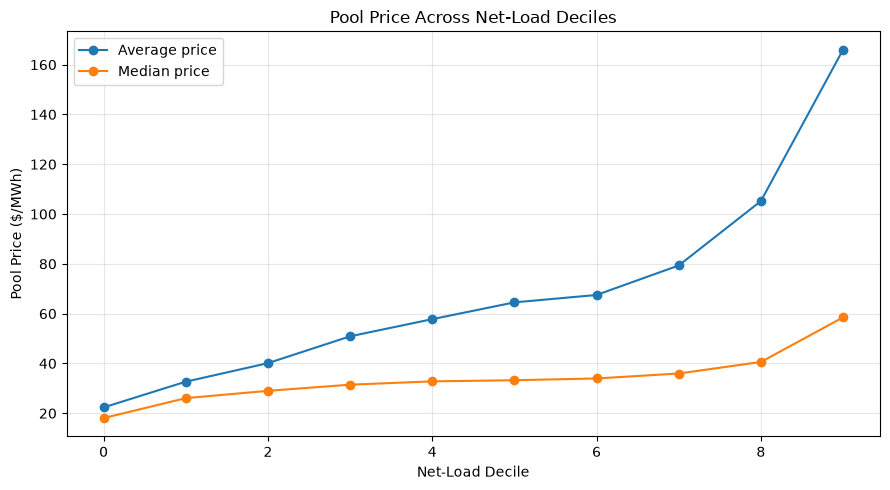

In [47]:
# ---------------------------------------------------------------------
# Summarize and visualize pool-price behaviour across net-load deciles
# ---------------------------------------------------------------------

netload_price_deciles = decile_relationship(
    relationship_df,
    "net_load",
    "price",
)

display(netload_price_deciles.round(2))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    netload_price_deciles.index,
    netload_price_deciles["average_target"],
    marker="o",
    label="Average price",
)
ax.plot(
    netload_price_deciles.index,
    netload_price_deciles["median_target"],
    marker="o",
    label="Median price",
)

ax.set_title("Pool Price Across Net-Load Deciles")
ax.set_xlabel("Net-Load Decile")
ax.set_ylabel("Pool Price ($/MWh)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


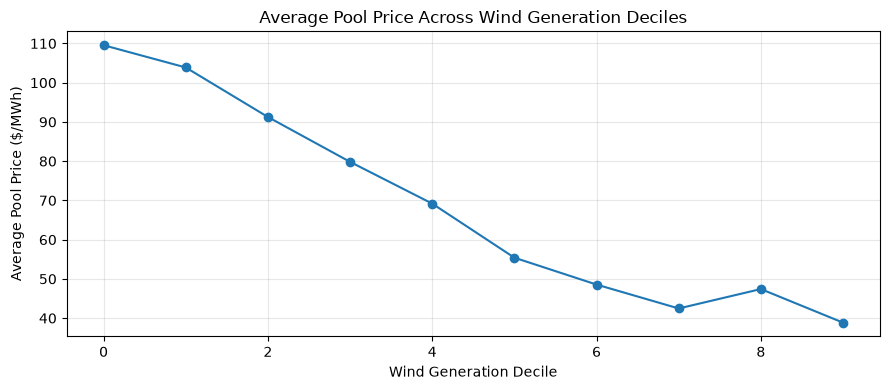

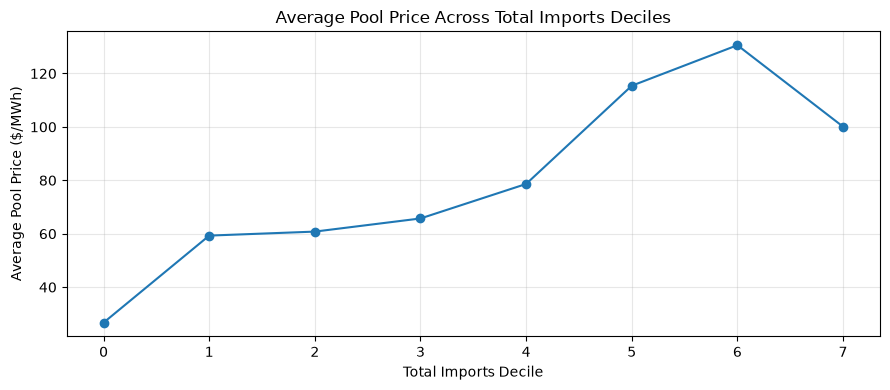

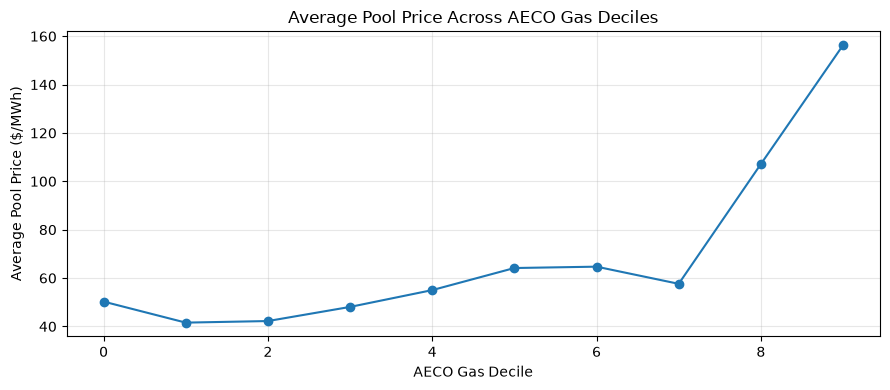

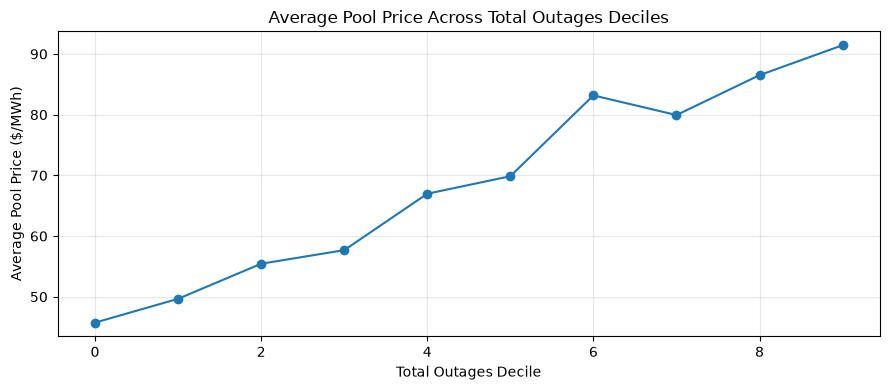

In [48]:
# ---------------------------------------------------------------------
# Compare pool-price behaviour across selected feature deciles
# ---------------------------------------------------------------------

features_to_test = {
    "Wind Generation": "wind",
    "Total Imports": "imports",
    "AECO Gas": "gas",
    "Total Outages": "outages",
}

decile_results = {}

for label, feature in features_to_test.items():
    summary = decile_relationship(relationship_df, feature, "price")
    decile_results[label] = summary

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(summary.index, summary["average_target"], marker="o")
    ax.set_title(f"Average Pool Price Across {label} Deciles")
    ax.set_xlabel(f"{label} Decile")
    ax.set_ylabel("Average Pool Price ($/MWh)")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


#### Price Response Across Variable Deciles

Net load has the clearest nonlinear relationship: prices rise gradually through most deciles and much faster near the top. Wind generally aligns with lower prices, while gas, outages, and imports align with higher prices over parts of their distributions.

The gas curve suggests a threshold interaction rather than a constant marginal effect. Imports can flatten at the highest stress levels if interties approach transfer limits while prices continue rising. These interpretations remain hypotheses until tested with interactions, lags, and capability controls.

### 6.3 Selected Scatterplots

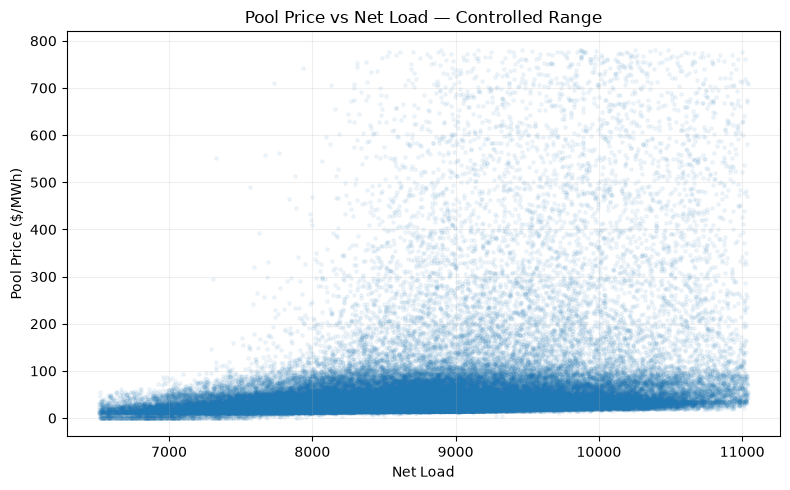

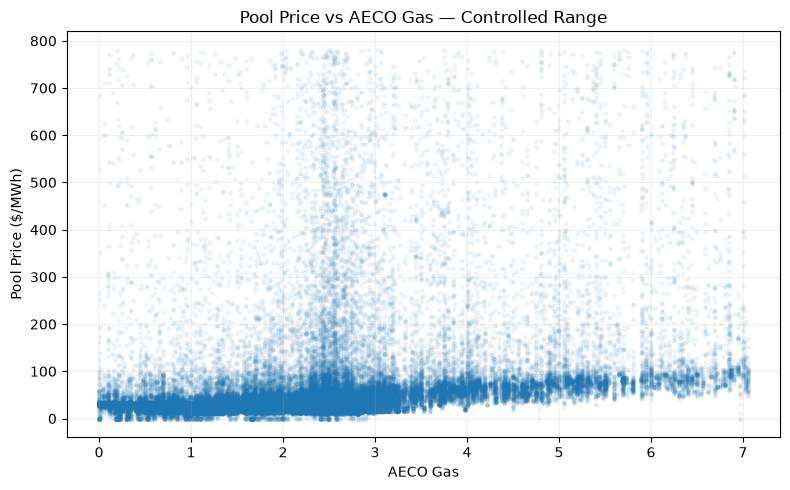

In [49]:
# ---------------------------------------------------------------------
# Visualize selected relationships within controlled display ranges
# ---------------------------------------------------------------------

scatter_features = {
    "Net Load": "net_load",
    "AECO Gas": "gas",
}

scatter_samples = {}
price_upper_limit = relationship_df["price"].quantile(0.99)

for label, column in scatter_features.items():
    feature_lower_limit = relationship_df[column].quantile(0.01)
    feature_upper_limit = relationship_df[column].quantile(0.99)

    sample = (
        relationship_df.loc[
            relationship_df["price"].le(price_upper_limit)
            & relationship_df[column].between(
                feature_lower_limit,
                feature_upper_limit,
            ),
            [column, "price"],
        ]
        .dropna()
        .copy()
    )

    scatter_samples[label] = sample

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sample[column], sample["price"], alpha=0.06, s=6)
    ax.set_title(f"Pool Price vs {label} — Controlled Range")
    ax.set_xlabel(label)
    ax.set_ylabel("Pool Price ($/MWh)")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


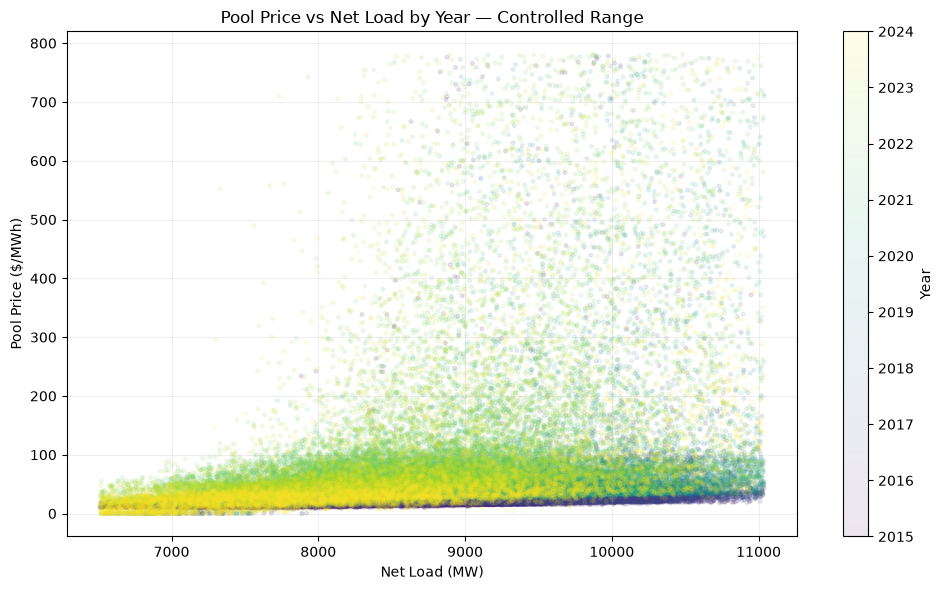

In [50]:
# ---------------------------------------------------------------------
# Visualize the net-load relationship across market regimes
# ---------------------------------------------------------------------

net_load_year_plot = pd.DataFrame({
    "net_load": net_load_for_analysis,
    "price": master["pool_price"],
    "year": master["year_alberta"],
}).dropna()

net_load_bounds = net_load_year_plot["net_load"].quantile([0.01, 0.99])
price_plot_limit = net_load_year_plot["price"].quantile(0.99)

net_load_year_plot = net_load_year_plot.loc[
    net_load_year_plot["net_load"].between(*net_load_bounds)
    & net_load_year_plot["price"].le(price_plot_limit)
]

fig, ax = plt.subplots(figsize=(10, 6))

points = ax.scatter(
    net_load_year_plot["net_load"],
    net_load_year_plot["price"],
    c=net_load_year_plot["year"],
    cmap="viridis",
    alpha=0.10,
    s=7,
)

ax.set_title("Pool Price vs Net Load by Year — Controlled Range")
ax.set_xlabel("Net Load (MW)")
ax.set_ylabel("Pool Price ($/MWh)")
ax.grid(alpha=0.2)
plt.colorbar(points, ax=ax, label="Year")

plt.tight_layout()
plt.show()


#### Scatterplot Relationships

Net load has the clearest positive association, but the wide vertical dispersion shows that similar net-load hours can produce very different prices. Gas displays the same limitation as a standalone explanation.

Colouring the net-load plot by year reveals that the relationship shifts across market regimes rather than following one stable curve. This supports explicit year or regime controls and time-aware validation in subsequent models.

## Questions Motivating Forecasting Analysis

| Exploratory observation | Testable hypothesis or next analysis |
|---|---|
| Reported maximum capacity increased while high-price events also increased | Available dispatchable capacity relative to net load should explain stress better than reported maximum capacity. |
| Net load has the strongest nonlinear price pattern | Because net load incorporates variable renewable output, it may outperform gross load during stressed conditions, particularly in the upper tail. Test this directly with AUC, precision-recall metrics, and time-based validation. |
| Imports rise with price but may flatten during extreme conditions | Imports primarily respond to stress; lagged flows and transfer-capability utilization should distinguish response from constraint saturation. |
| Wind and renewable share are negatively associated with price | Renewable value depends on season, hour, load, installed capacity, and concurrent output. |
| Gas is weak through much of its range and stronger near the top | Gas has a regime-dependent interaction with net load or system tightness. |
| High-price events cluster by month and year | Persistent market regimes require time-aware validation and explicit regime features. |
| Summer and winter both show elevated stress | Seasonal mechanisms differ and should be modelled through weather, outages, demand, and renewable interactions. |

These hypotheses provide the bridge from market orientation to feature engineering, causal caution, and forecasting in subsequent notebooks.